In [9]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

# Load the datasets
m2_df = pd.read_csv('macro/fredData/m2.csv')
btc_df = pd.read_csv('micro/assetData/bitcoin.csv')

# Convert dates to datetime
m2_df['date'] = pd.to_datetime(m2_df['date'])
btc_df['date'] = pd.to_datetime(btc_df['date'])

# Filter M2 data to match Bitcoin's date range
m2_df = m2_df[m2_df['date'] >= btc_df['date'].min()]
m2_df = m2_df[m2_df['date'] <= btc_df['date'].max()]


m2_df['yoy'] = m2_df['m2'].pct_change(periods=12) * 100

# Calculate variations for Bitcoin (using price column)

btc_df['yoy'] = btc_df.iloc[:, 1].pct_change(periods=365) * 100

# Create dual-axis YoY comparison plot
fig_yoy = go.Figure()
fig_yoy.add_trace(go.Scatter(x=m2_df['date'], y=m2_df['yoy'], name='M2 YoY', line=dict(color='blue')))
fig_yoy.add_trace(go.Scatter(x=btc_df['date'], y=btc_df['yoy'], name='Bitcoin YoY', 
                            line=dict(color='orange'), yaxis='y2'))
fig_yoy.update_layout(
    title='Year-over-Year Variations: M2 vs Bitcoin',
    xaxis_title='Date',
    yaxis_title='M2 Variation (%)',
    yaxis2=dict(title='Bitcoin Variation (%)', overlaying='y', side='right'),
    legend=dict(x=1.1, y=1)
)


fig_yoy.show()

In [11]:
import requests

url = "https://api.db.nomics.world/v22/series/ISM/pmi?facets=1&format=json&limit=1000&observations=1"
response = requests.get(url)
data = response.json()
print(data)

{'_meta': {'args': {'align_periods': False, 'dataset_code': 'pmi', 'dimensions': {}, 'facets': True, 'format': 'json', 'limit': 1000, 'metadata': True, 'observations': True, 'offset': 0, 'provider_code': 'ISM', 'q': '', 'series_code': None}, 'version': '22.1.17'}, 'dataset': {'code': 'pmi', 'dimensions_codes_order': ['frequency'], 'dimensions_labels': {'frequency': 'Frequency'}, 'dimensions_values_labels': {'frequency': {'M': 'Monthly'}}, 'dir_hash': '281b1f57e08e66f2d02fc328fd53df175a005d2f', 'indexed_at': '2025-01-05T02:13:19.536Z', 'name': 'Manufacturing - PMI', 'nb_series': 1, 'next_release_at': '2025-02-03', 'provider_code': 'ISM', 'provider_name': 'Institute for Supply Management'}, 'errors': None, 'provider': {'code': 'ISM', 'indexed_at': '2025-02-03T03:04:34.394Z', 'name': 'Institute for Supply Management', 'region': 'US', 'slug': 'ism', 'terms_of_use': 'https://www.ismworld.org/footer/terms-of-use/', 'website': 'https://www.ismworld.org'}, 'series': {'docs': [{'@frequency': 'm

In [16]:
import requests
import pandas as pd

def parse_pmi_json(json_data):
    """
    Parses PMI data from the given JSON.
    """
    try:
        # 'json_data' is already a Python dictionary, so we can just extract from it
        series_data = json_data["series"]["docs"][0]

        periods = series_data["period"]  # List of time periods (monthly)
        values = series_data["value"]    # Corresponding PMI values

        # Create a DataFrame
        df = pd.DataFrame({
            "Date": pd.to_datetime(periods),
            "PMI": values
        })

        df.sort_values("Date", inplace=True)  # Ensure chronological order
        df.set_index("Date", inplace=True)    # Set Date as index
        return df
    except Exception as e:
        print(f"Error parsing JSON: {e}")
        return None

if __name__ == "__main__":
    url = "https://api.db.nomics.world/v22/series/ISM/pmi?facets=1&format=json&limit=1000&observations=1"
    response = requests.get(url)
    data = response.json()

    # Parse the JSON into a DataFrame
    df_pmi = parse_pmi_json(data)

    if df_pmi is not None:
        print(df_pmi)


             PMI
Date            
2020-05-01  43.1
2020-06-01  52.2
2020-07-01  53.7
2020-08-01  55.6
2020-09-01  55.7
2020-10-01  58.8
2020-11-01  57.7
2020-12-01  60.5
2021-01-01  58.7
2021-02-01  60.9
2021-03-01  63.7
2021-04-01  60.6
2021-05-01  61.6
2021-06-01  60.9
2021-07-01  59.9
2021-08-01  59.7
2021-09-01  60.5
2021-10-01  60.8
2021-11-01  60.6
2021-12-01  58.8
2022-01-01  57.6
2022-02-01  58.4
2022-03-01  57.0
2022-04-01  55.9
2022-05-01  56.1
2022-06-01  53.1
2022-07-01  52.7
2022-08-01  52.9
2022-09-01  51.0
2022-10-01  50.0
2022-11-01  49.0
2022-12-01  48.4
2023-01-01  47.4
2023-02-01  47.7
2023-03-01  46.5
2023-04-01  47.0
2023-05-01  46.6
2023-06-01  46.4
2023-07-01  46.5
2023-08-01  47.6
2023-09-01  48.6
2023-10-01  46.9
2023-11-01  46.6
2023-12-01  47.1
2024-01-01  49.1
2024-02-01  47.8
2024-03-01  50.3
2024-04-01  49.2
2024-05-01  48.7
2024-06-01  48.5
2024-07-01  46.8
2024-08-01  47.2
2024-09-01  47.2
2024-10-01  46.5
2024-11-01  48.4
2024-12-01  49.3


In [3]:
import yfinance as yf

# Define the ticker for the US Dollar Index
ticker = "DX-Y.NYB"

# Create a Ticker object
dxy = yf.Ticker(ticker)

# Get the historical market data; 'max' retrieves all available data
dxy_data = dxy.history(period="max")

# Display the first few rows of the data
print(dxy_data.head())


                                 Open        High         Low       Close  \
Date                                                                        
1971-01-04 00:00:00-05:00  120.529999  120.529999  120.529999  120.529999   
1971-01-05 00:00:00-05:00  120.519997  120.519997  120.519997  120.519997   
1971-01-06 00:00:00-05:00  120.489998  120.489998  120.489998  120.489998   
1971-01-07 00:00:00-05:00  120.550003  120.550003  120.550003  120.550003   
1971-01-08 00:00:00-05:00  120.529999  120.529999  120.529999  120.529999   

                           Volume  Dividends  Stock Splits  
Date                                                        
1971-01-04 00:00:00-05:00       0        0.0           0.0  
1971-01-05 00:00:00-05:00       0        0.0           0.0  
1971-01-06 00:00:00-05:00       0        0.0           0.0  
1971-01-07 00:00:00-05:00       0        0.0           0.0  
1971-01-08 00:00:00-05:00       0        0.0           0.0  


In [4]:
print(dxy_data.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2025-02-03 00:00:00-05:00  108.500000  109.879997  108.339996  108.989998   
2025-02-04 00:00:00-05:00  108.680000  109.040001  107.919998  107.959999   
2025-02-05 00:00:00-05:00  108.010002  108.010002  107.300003  107.580002   
2025-02-06 00:00:00-05:00  107.620003  108.099998  107.540001  107.690002   
2025-02-07 00:00:00-05:00  107.698997  108.022003  107.515999  107.664001   

                           Volume  Dividends  Stock Splits  
Date                                                        
2025-02-03 00:00:00-05:00       0        0.0           0.0  
2025-02-04 00:00:00-05:00       0        0.0           0.0  
2025-02-05 00:00:00-05:00       0        0.0           0.0  
2025-02-06 00:00:00-05:00       0        0.0           0.0  
2025-02-07 00:00:00-05:00       0        0.0           0.0  


In [5]:
import os
import pandas as pd
import plotly.graph_objects as go

# Define the path to the CSV file (adjust if necessary)
csv_path = os.path.join("macro", "fredData", "yieldCurveRegime.csv")
try:
    df = pd.read_csv(csv_path)
except Exception as e:
    print(f"Error loading CSV file from {csv_path}: {e}")
    exit()

# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Define a test date range (adjust as needed)
start_date = pd.to_datetime("1976-06-29")
end_date   = pd.to_datetime("2025-01-01")

# Filter the DataFrame by the date range and reset its index


# Create the base figure that plots the spread as a black line.
fig = go.Figure()

# Base spread line trace
fig.add_trace(go.Scatter(
    x=df['date'],
    y=df['spread'],
    mode='lines',
    name='Spread',
    line=dict(color='black', width=2)
))

# -------------------------------------------------------------------
# Group the data into contiguous blocks based on the regime value.
# -------------------------------------------------------------------
blocks = []
current_regime = df.loc[0, 'regime']
current_color = df.loc[0, 'color']
start_idx = 0

for i in range(1, len(df)):
    regime = df.loc[i, 'regime']
    if regime != current_regime:
        # Save the block of contiguous rows with the current regime.
        blocks.append((start_idx, i - 1, current_regime, current_color))
        start_idx = i
        current_regime = regime
        current_color = df.loc[i, 'color']

# Append the final block.
blocks.append((start_idx, len(df) - 1, current_regime, current_color))

# -------------------------------------------------------------------
# For each contiguous regime block, overlay an area plot.
# The area plot uses the same spread values, but the fill is
# color coded based on the regime.
# -------------------------------------------------------------------
for block in blocks:
    s_idx, e_idx, block_regime, block_color = block
    block_data = df.iloc[s_idx:e_idx+1]
    fig.add_trace(go.Scatter(
        x = block_data['date'],
        y = block_data['spread'],
        mode = 'lines',
        name = f"{block_regime} area",
        line = dict(width=0),  # hide line details for the area trace
        fill = 'tozeroy',       # fill from the line to y=0
        fillcolor = block_color,  # using the hex color from the CSV
        opacity = 0.3,
        showlegend = False,
        hoverinfo = 'skip'
    ))

# Update the layout of the figure.
fig.update_layout(
    title="2-10 Year Treasury Spread with Regime Color-Coded Area Overlay",
    xaxis_title="Date",
    yaxis_title="Spread",
    template="plotly_white",
)

# Show the figure (this works in a Jupyter Notebook environment)
fig.show()


Summary Statistics:
            regime  cum_return  volatility  days
0   bear_flattener       -3.39       75.38   523
1   bear_steepener      -11.17       66.35   653
2   bull_flattener      547.20       63.91   590
3   bull_steepener      234.63       76.78   351
4  flattener_twist      263.17       68.15   201
5          neutral      -34.96       69.76   285
6  steepener_twist      123.93       80.70   353


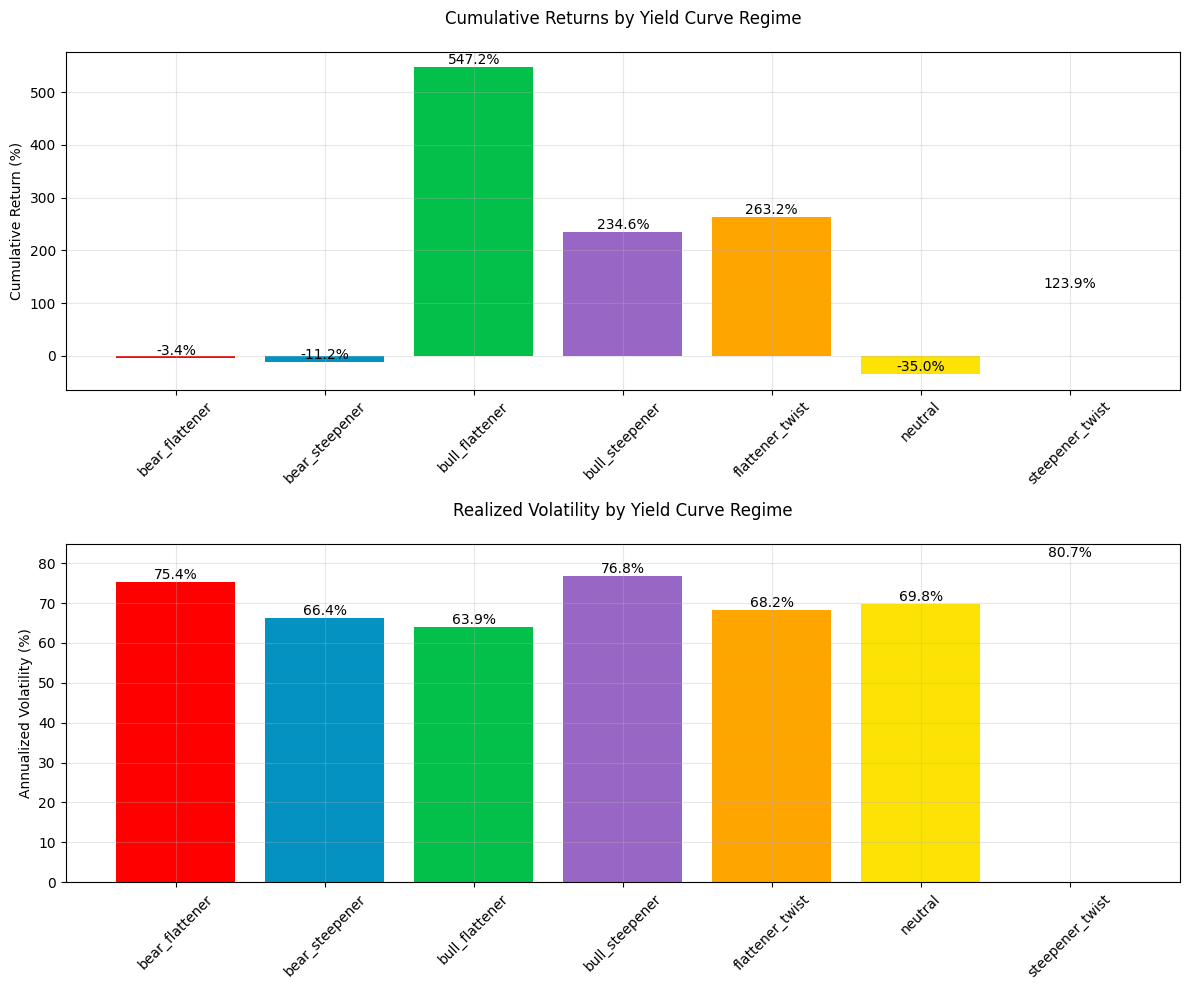

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
def load_data():
    yield_curve = pd.read_csv('macro/fredData/yieldCurveRegime.csv', parse_dates=[0])
    btc = pd.read_csv('micro/candleData/bitcoin_candles.csv', parse_dates=[0])
    
    # Set dates as index
    yield_curve.set_index('date', inplace=True)
    btc.set_index('date', inplace=True)
    
    # Filter BTC data from 2017 onwards
    #btc = btc[btc.index >= '2017-01-01']
    
    # Filter yield curve data to match Bitcoin's date range
    yield_curve = yield_curve[yield_curve.index >= '2017-01-01']
    
    return yield_curve, btc

def calculate_metrics(yield_curve, btc):
    # Calculate daily returns based on close prices (assumed to be in the fourth column)
    btc['returns'] = btc.iloc[:, 3].pct_change()

    # Reset indices for merging operations
    btc_reset = btc.reset_index()
    yield_curve_reset = yield_curve.reset_index()

    # Merge BTC data with yield curve regime information using merge_asof.
    # This ensures every BTC day gets the most recent regime info from the yield curve,
    # so that the last available regime persists over gaps (e.g., weekends, holidays).
    merged_df = pd.merge_asof(
        btc_reset.sort_values('date'),
        yield_curve_reset.sort_values('date')[['date', 'regime']],
        on='date',
        direction='backward'
    )

    # Initialize results dictionary
    results = {
        'regime': [],
        'cum_return': [],
        'volatility': [],
        'days': []
    }

    # Group the merged data by regime and calculate metrics
    for regime, group in merged_df.groupby('regime'):
        if group.empty:
            continue

        # Calculate cumulative return for the regime
        cum_return = (1 + group['returns']).prod() - 1
        # Calculate realized volatility from daily returns and annualize by 365 (24/7 market)
        volatility = np.std(group['returns']) * np.sqrt(365)

        results['regime'].append(regime)
        results['cum_return'].append(cum_return * 100)  # Convert to percentage
        results['volatility'].append(volatility * 100)    # Convert to percentage
        results['days'].append(len(group))

    return pd.DataFrame(results)

def plot_results(results):
    # Use a basic matplotlib style instead of seaborn
    plt.style.use('default')
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot cumulative returns
    colors = ['#FF0000', '#0492C2', '#03C04A', '#9867C5', '#FFA500', '#FCE205', '#FFFFFF']
    bars1 = ax1.bar(results['regime'], results['cum_return'], color=colors)
    ax1.set_title('Cumulative Returns by Yield Curve Regime', pad=20)
    ax1.set_ylabel('Cumulative Return (%)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # Plot volatility
    bars2 = ax2.bar(results['regime'], results['volatility'], color=colors)
    ax2.set_title('Realized Volatility by Yield Curve Regime', pad=20)
    ax2.set_ylabel('Annualized Volatility (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()  # Just show the plot instead of saving it


# ... rest of the code remains the same ...

def main():
    # Load data
    yield_curve, btc = load_data()
    
    # Calculate metrics
    results = calculate_metrics(yield_curve, btc)
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print(results.round(2))
    
    # Plot results
    plot_results(results)

if __name__ == "__main__":
    main()


Analyzing dxy...


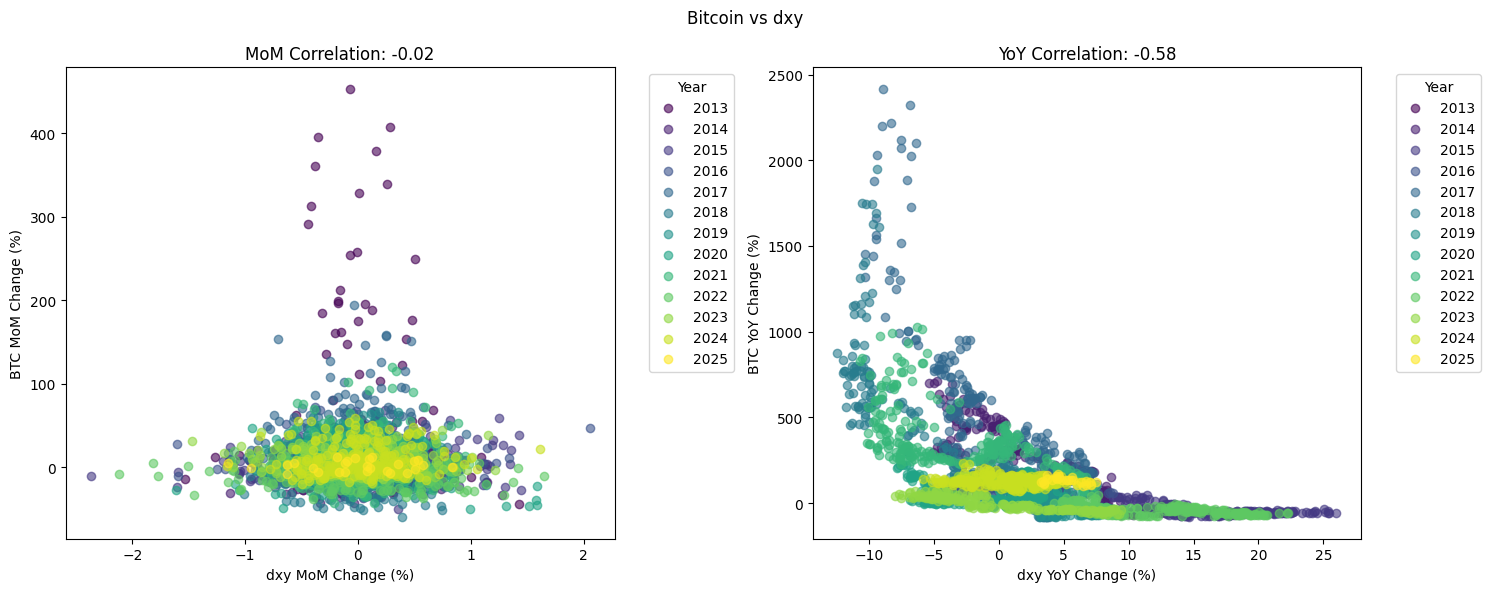


Analyzing durableGoods...


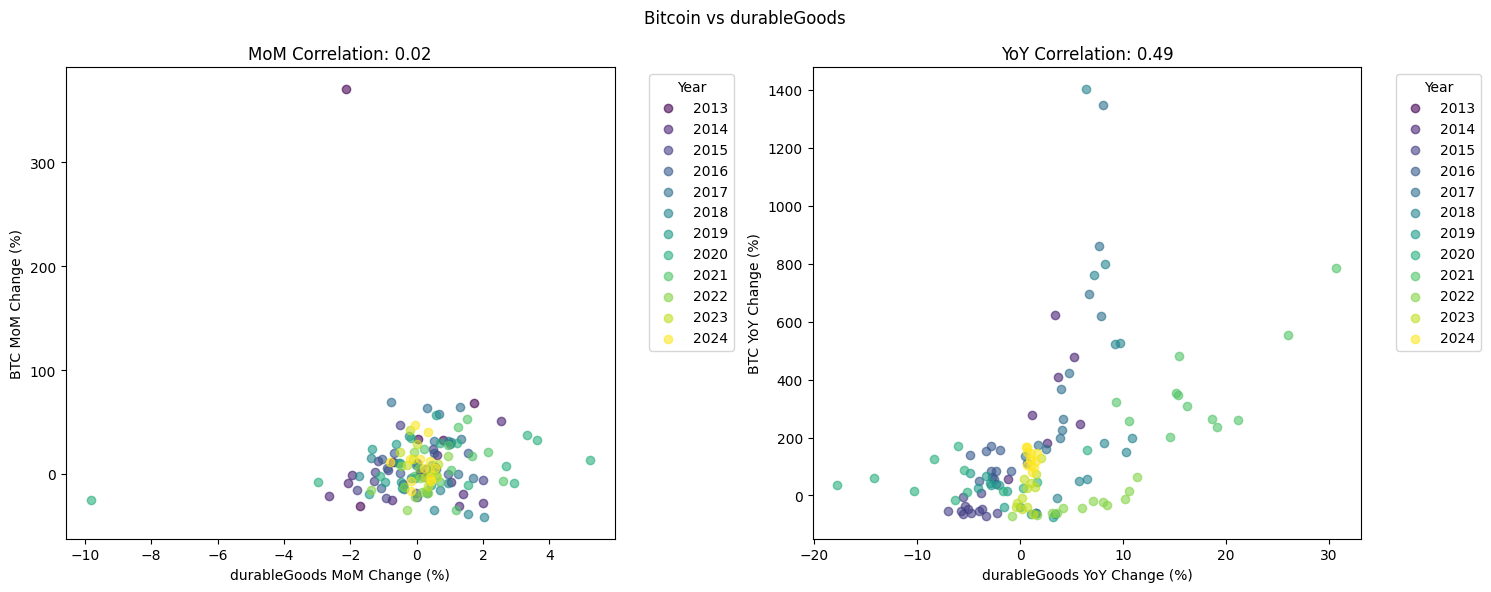


Analyzing creditSpreadsHighGrade...


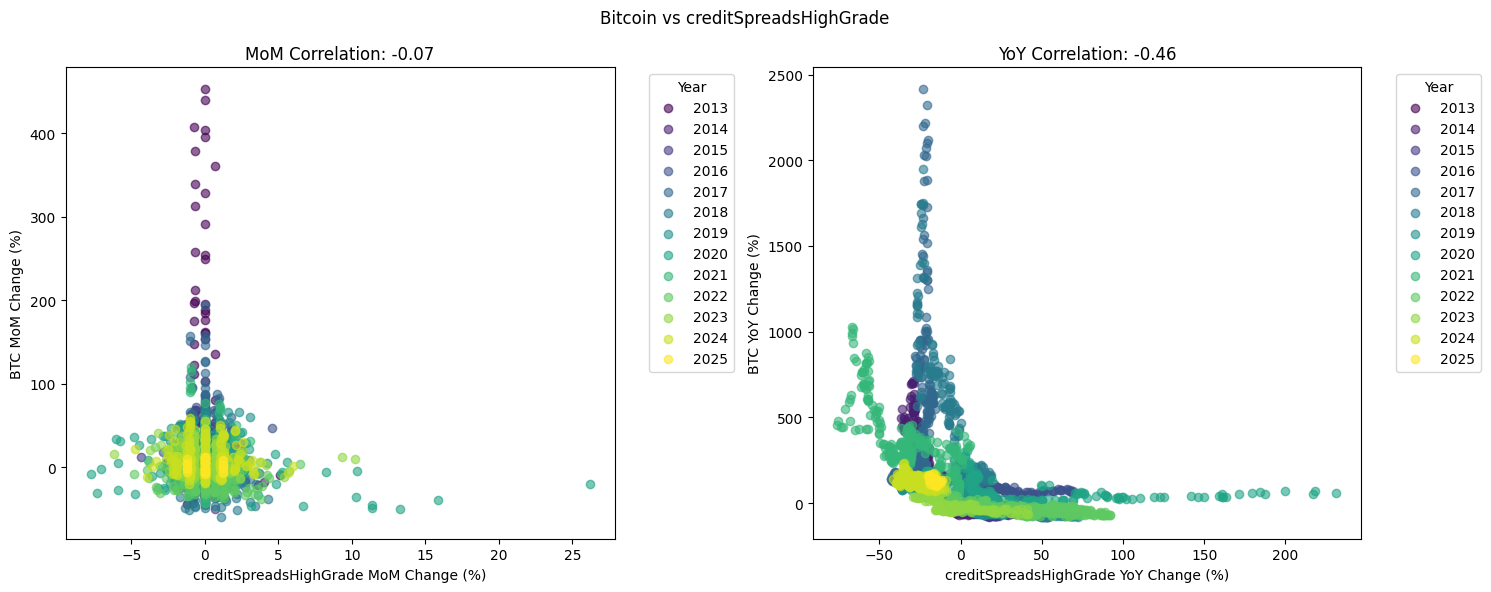


Analyzing creditSpreads...


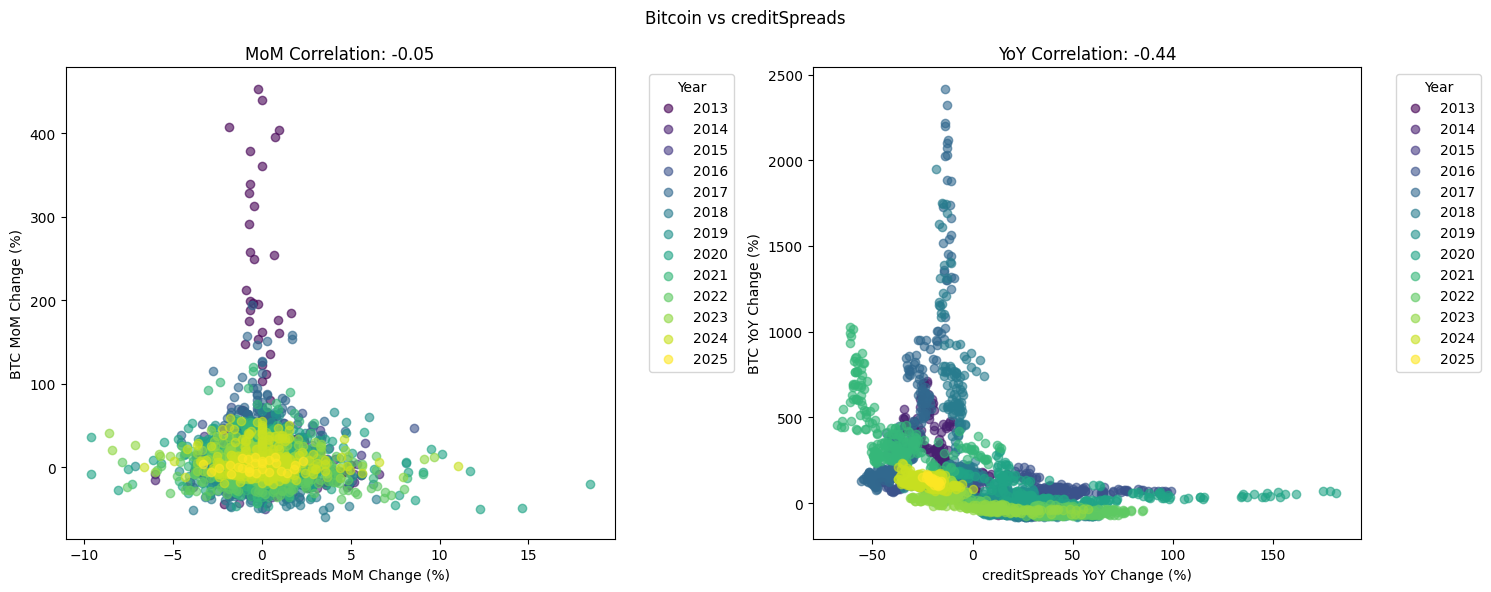


Analyzing realGDP...


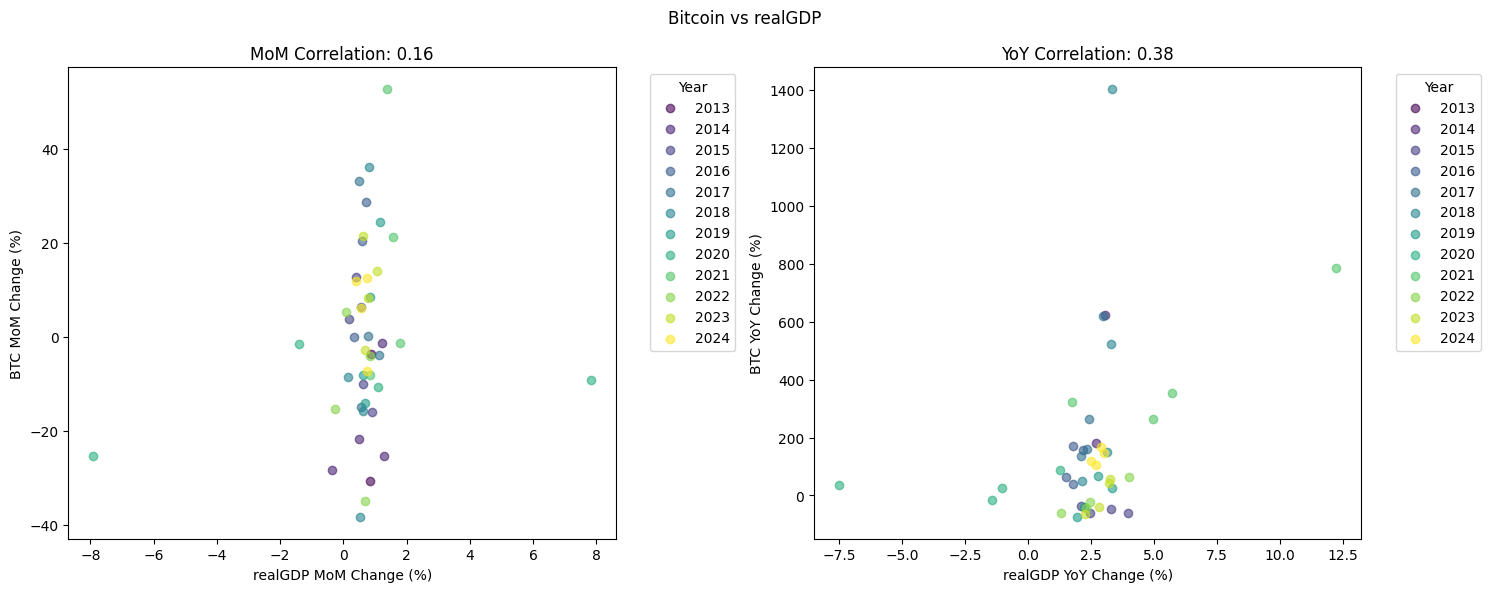


Analyzing move...


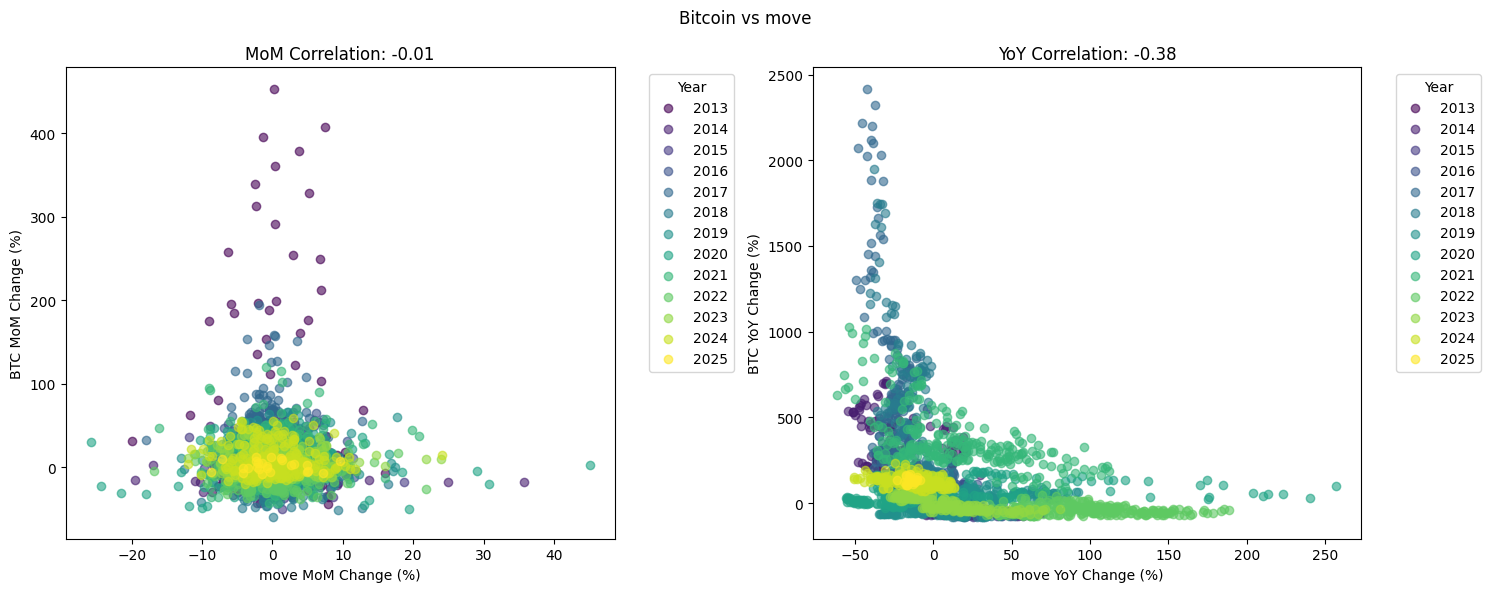


Analyzing vix...


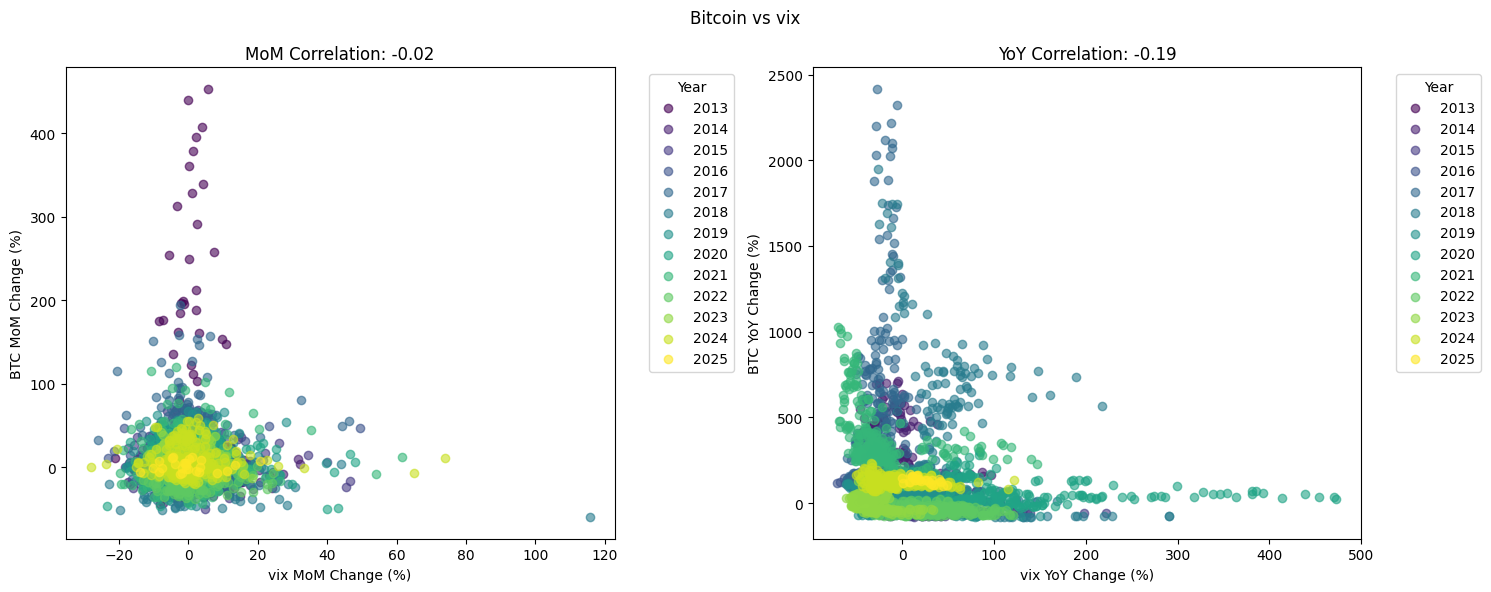


Analyzing treasury5YInflationForwardRate...


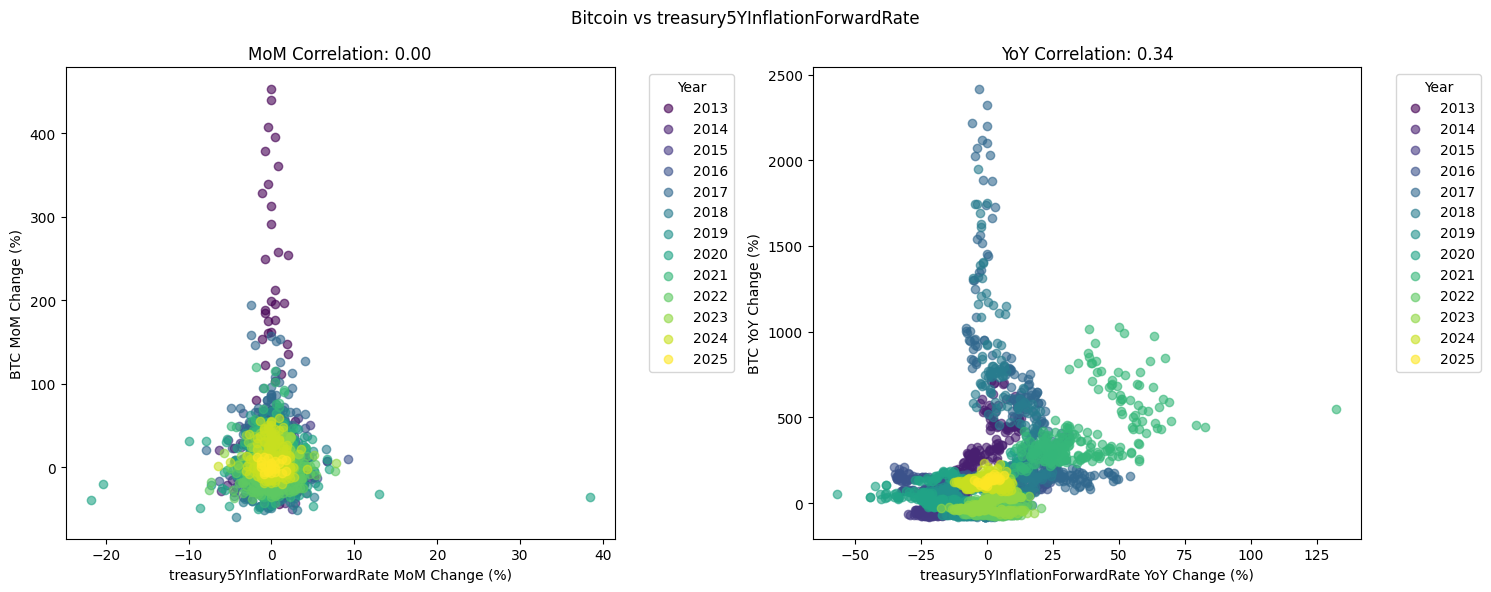


Analyzing globalCbLiquidity...


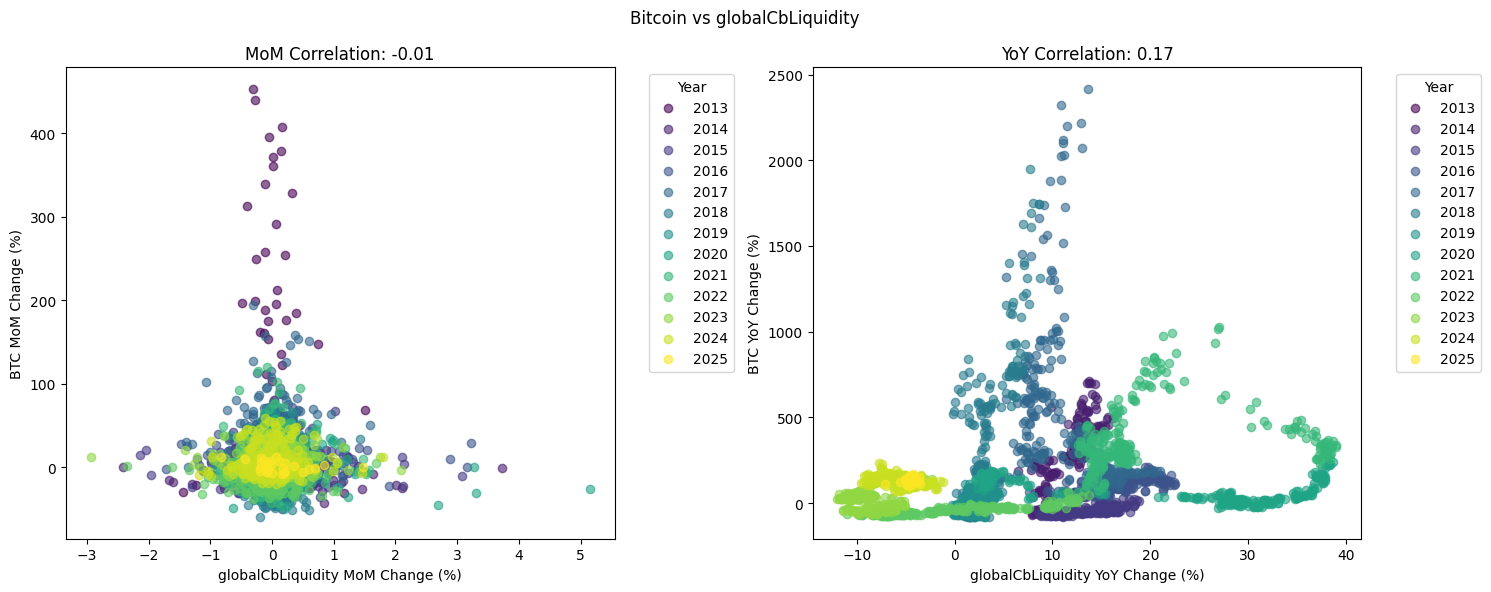


Analyzing m2...


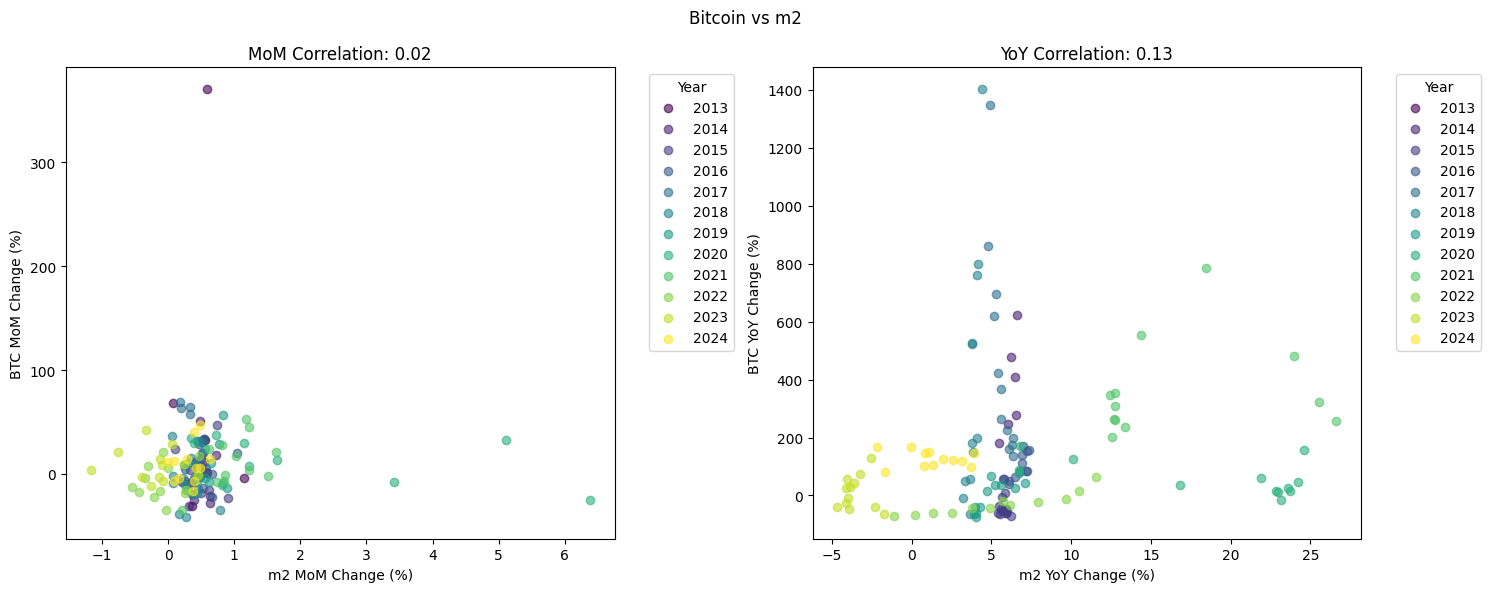


Analyzing financialConditionsIndex...


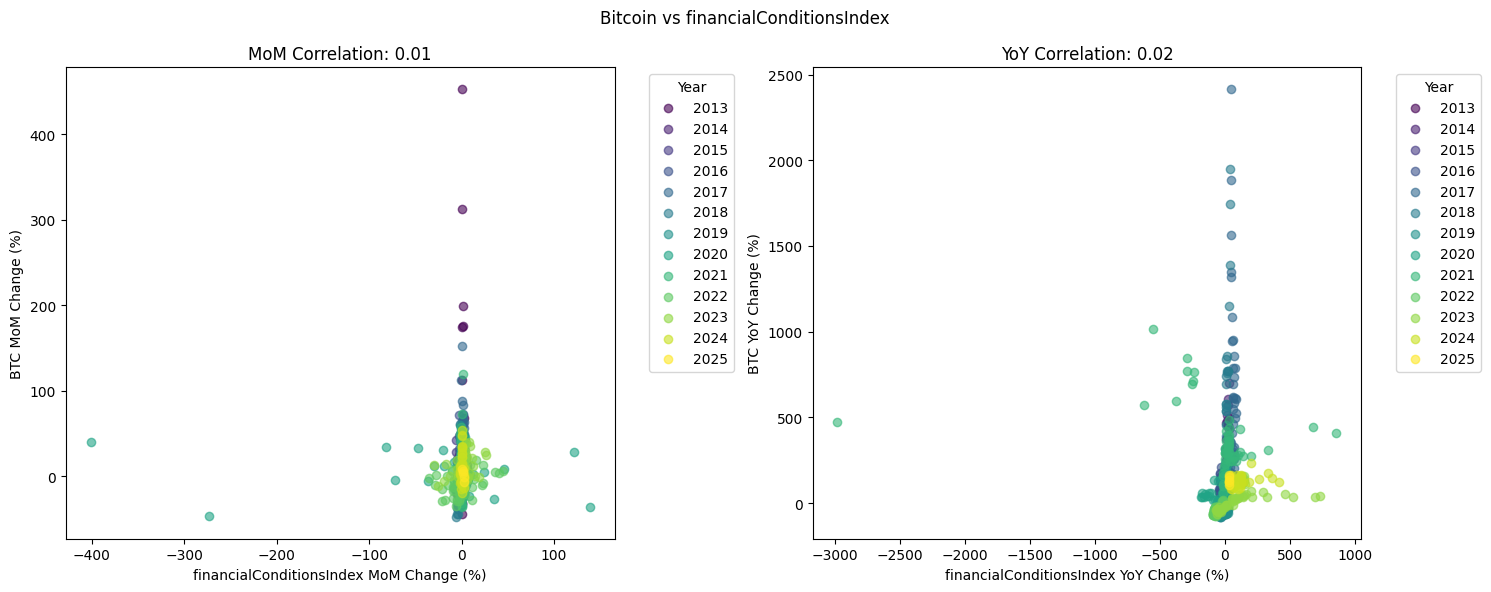


Correlation Summary:
                          Variable  MoM_Correlation  YoY_Correlation
0                              dxy        -0.020856        -0.575048
1                     durableGoods         0.024839         0.489370
2           creditSpreadsHighGrade        -0.071955        -0.463881
3                    creditSpreads        -0.050716        -0.439229
4                          realGDP         0.157468         0.381498
5                             move        -0.007790        -0.377537
7   treasury5YInflationForwardRate         0.001760         0.339176
6                              vix        -0.021017        -0.189395
8                globalCbLiquidity        -0.011790         0.166745
9                               m2         0.017927         0.125312
10        financialConditionsIndex         0.013090         0.015141


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# List of specific variables we want to analyze
MACRO_VARS = [
    'dxy', 
    'durableGoods',
    'creditSpreadsHighGrade',
    'creditSpreads',
    'realGDP',
    'move',
    'vix',
    'treasury5YInflationForwardRate',
    'globalCbLiquidity',
    'm2',
    'financialConditionsIndex'
]

def load_and_prepare_btc():
    """Load BTC data and calculate returns"""
    df = pd.read_csv('micro/assetData/bitcoin.csv')
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Calculate returns using close price (first column)
    df['BTC_MoM'] = df.iloc[:, 0].pct_change(30) * 100  # 30-day return
    df['BTC_YoY'] = df.iloc[:, 0].pct_change(365) * 100  # 365-day return
    
    return df[['BTC_MoM', 'BTC_YoY']]

def load_macro_var(var_name):
    """Load and prepare macro variable data"""
    try:
        # Look for the file in fredChanges directory
        file_path = next(Path('macro/fredChanges').glob(f'{var_name}_changes_*.csv'))
        df = pd.read_csv(file_path)
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        return df[['MoM', 'YoY']]
    except Exception as e:
        print(f"Error loading {var_name}: {e}")
        return None

def plot_relationships(btc_data, macro_data, macro_name):
    """Create scatter plots for MoM and YoY relationships with dots colored by year"""
    # Merge the data
    merged = pd.merge(btc_data, macro_data, 
                     left_index=True, right_index=True,
                     how='inner')
    
    # Extract years for coloring
    years = merged.index.year
    unique_years = sorted(set(years))
    
    # Create a colormap
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(unique_years)))
    year_to_color = dict(zip(unique_years, colors))
    
    # Calculate correlations
    mom_corr = merged['BTC_MoM'].corr(merged['MoM'])
    yoy_corr = merged['BTC_YoY'].corr(merged['YoY'])
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # MoM plot
    for year in unique_years:
        mask = years == year
        ax1.scatter(merged.loc[mask, 'MoM'], 
                   merged.loc[mask, 'BTC_MoM'], 
                   alpha=0.6,
                   color=year_to_color[year],
                   label=str(year))
    
    ax1.set_xlabel(f'{macro_name} MoM Change (%)')
    ax1.set_ylabel('BTC MoM Change (%)')
    ax1.set_title(f'MoM Correlation: {mom_corr:.2f}')
    ax1.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # YoY plot
    for year in unique_years:
        mask = years == year
        ax2.scatter(merged.loc[mask, 'YoY'], 
                   merged.loc[mask, 'BTC_YoY'], 
                   alpha=0.6,
                   color=year_to_color[year],
                   label=str(year))
    
    ax2.set_xlabel(f'{macro_name} YoY Change (%)')
    ax2.set_ylabel('BTC YoY Change (%)')
    ax2.set_title(f'YoY Correlation: {yoy_corr:.2f}')
    ax2.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.suptitle(f'Bitcoin vs {macro_name}')
    plt.tight_layout()
    plt.show()
    
    return mom_corr, yoy_corr

# Load BTC data
btc_data = load_and_prepare_btc()

# Store results
results = []

# Process each macro variable
for var_name in MACRO_VARS:
    print(f"\nAnalyzing {var_name}...")
    
    # Load macro data
    macro_data = load_macro_var(var_name)
    if macro_data is not None:
        # Plot relationships and get correlations
        mom_corr, yoy_corr = plot_relationships(btc_data, macro_data, var_name)
        
        # Store results
        results.append({
            'Variable': var_name,
            'MoM_Correlation': mom_corr,
            'YoY_Correlation': yoy_corr
        })

# Create and display summary DataFrame
summary = pd.DataFrame(results)
summary['Abs_YoY_Corr'] = abs(summary['YoY_Correlation'])
summary = summary.sort_values('Abs_YoY_Corr', ascending=False)
summary.drop('Abs_YoY_Corr', axis=1, inplace=True)

print("\nCorrelation Summary:")
print(summary)


Analyzing realGDP...


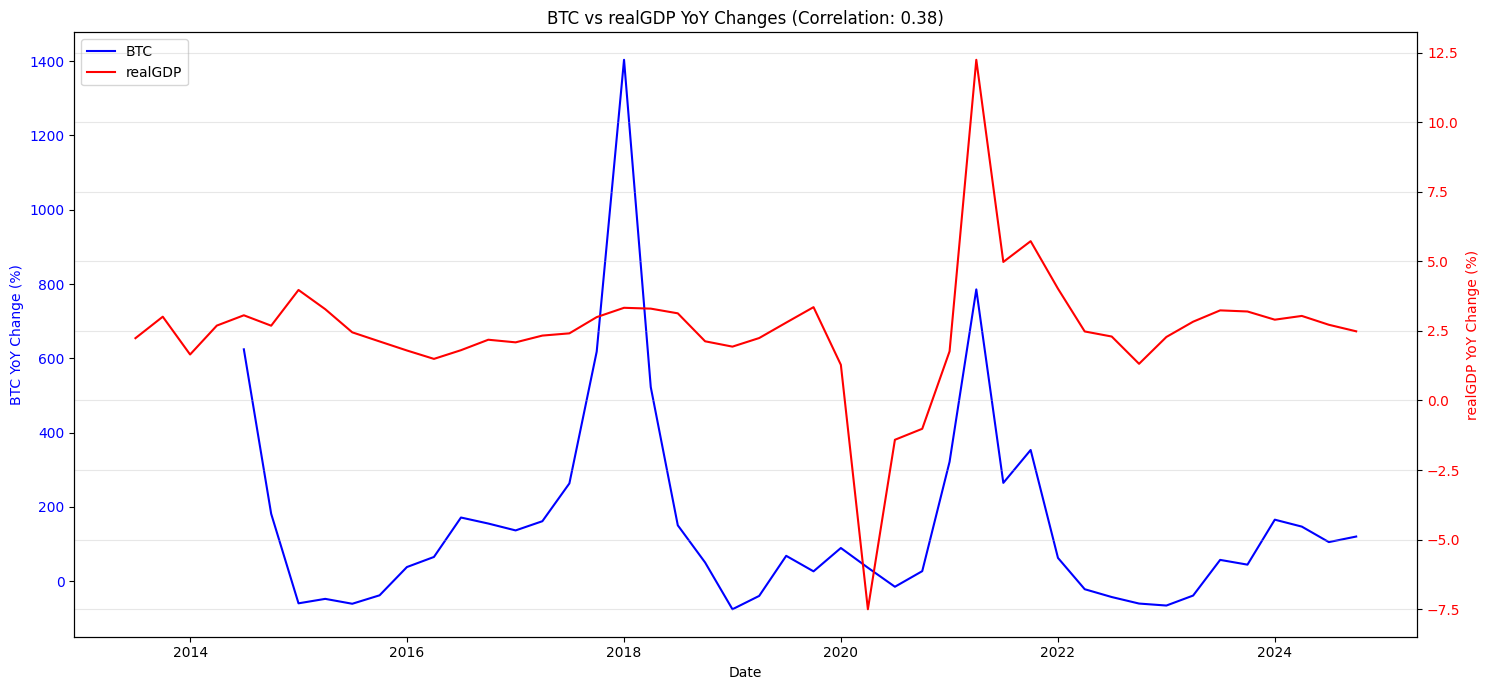


Analyzing pceTrimmedMean12M...


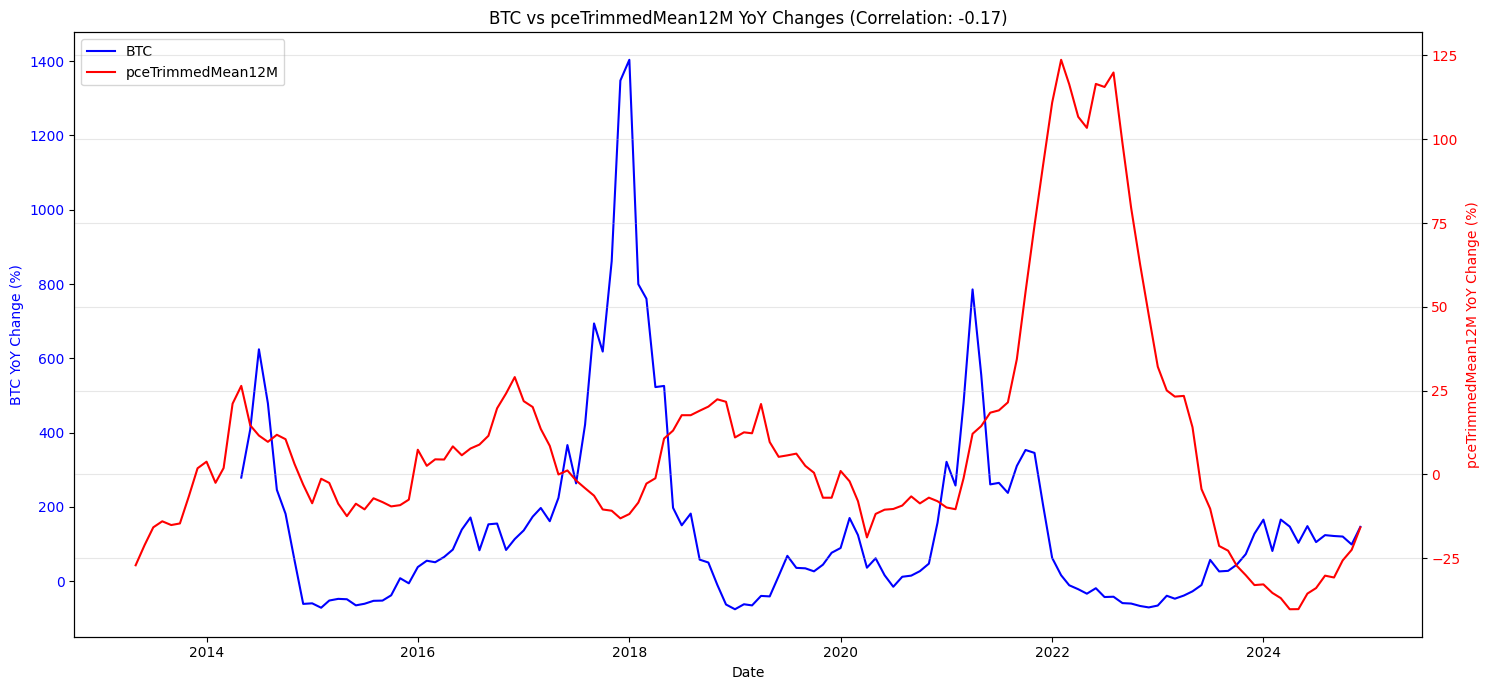


Analyzing m2...


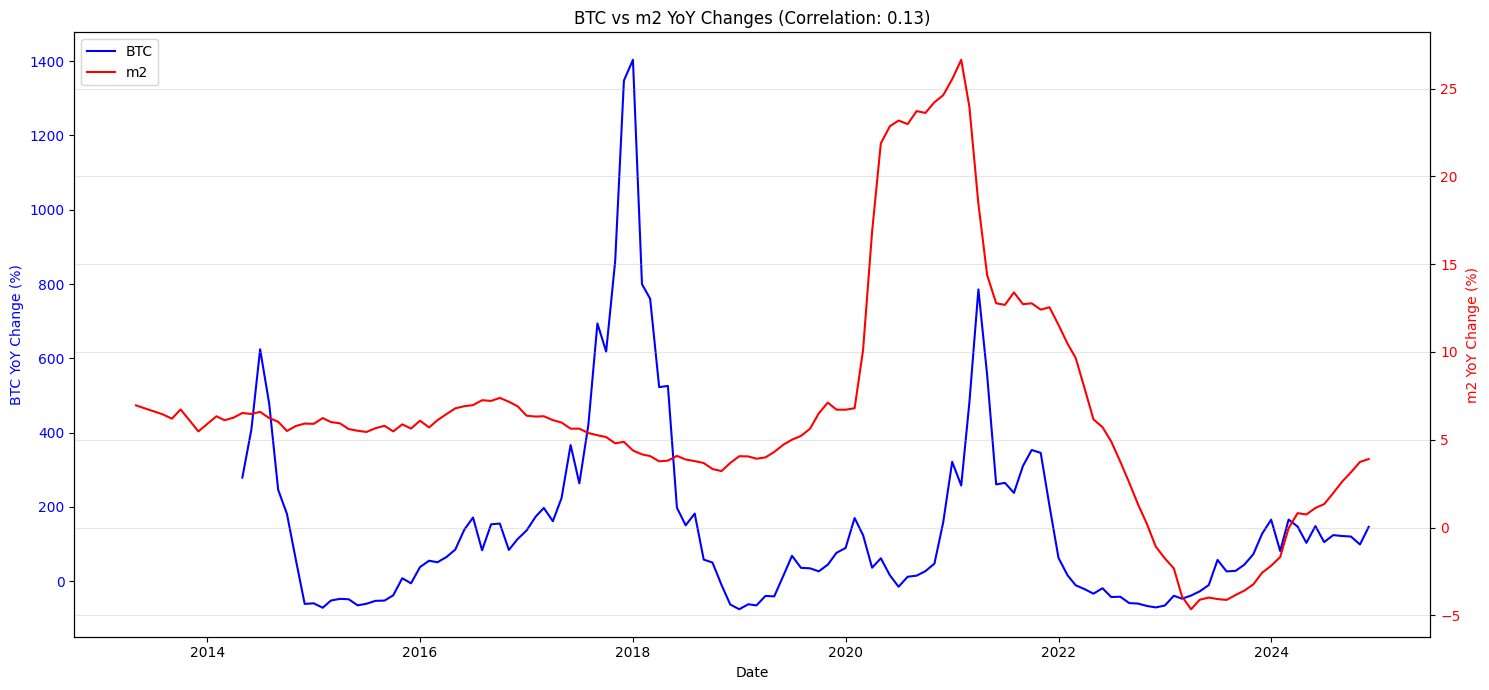


Analyzing globalCbLiquidity...


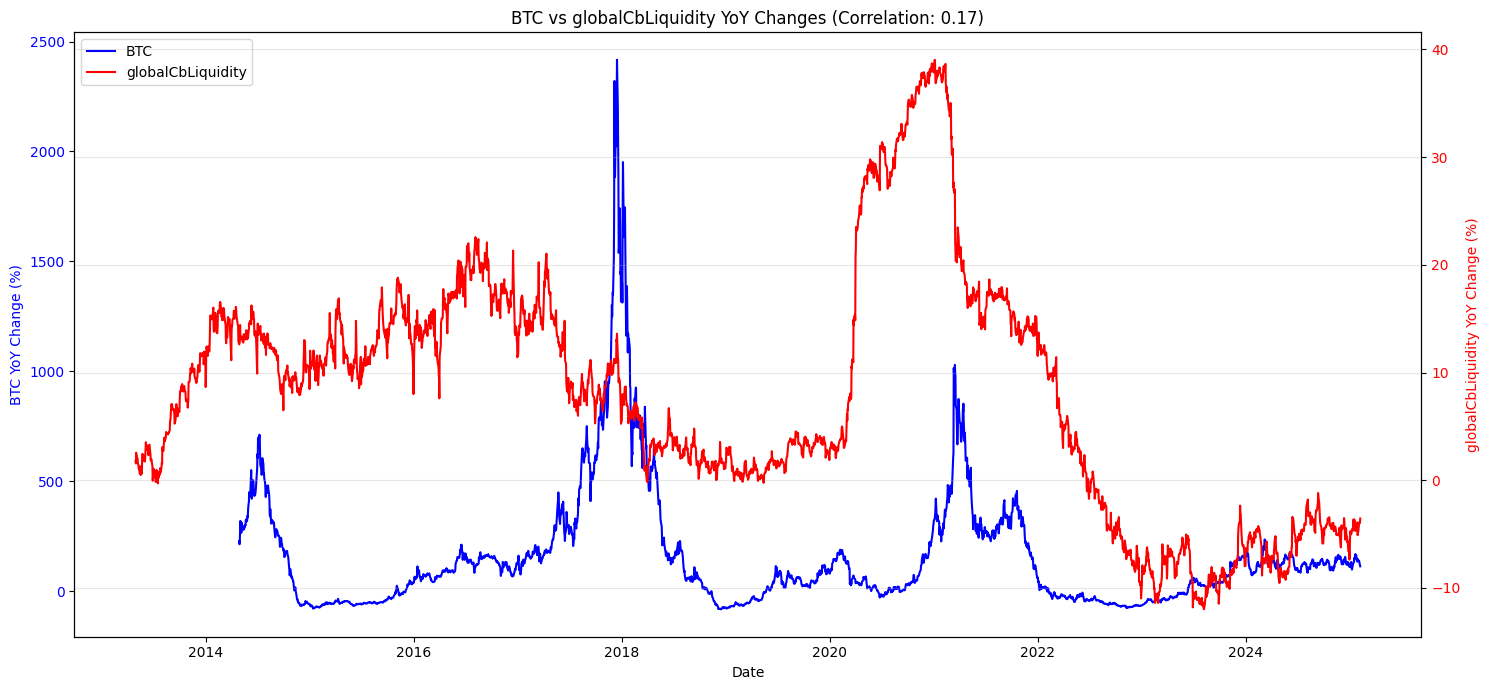


Analyzing dxy...


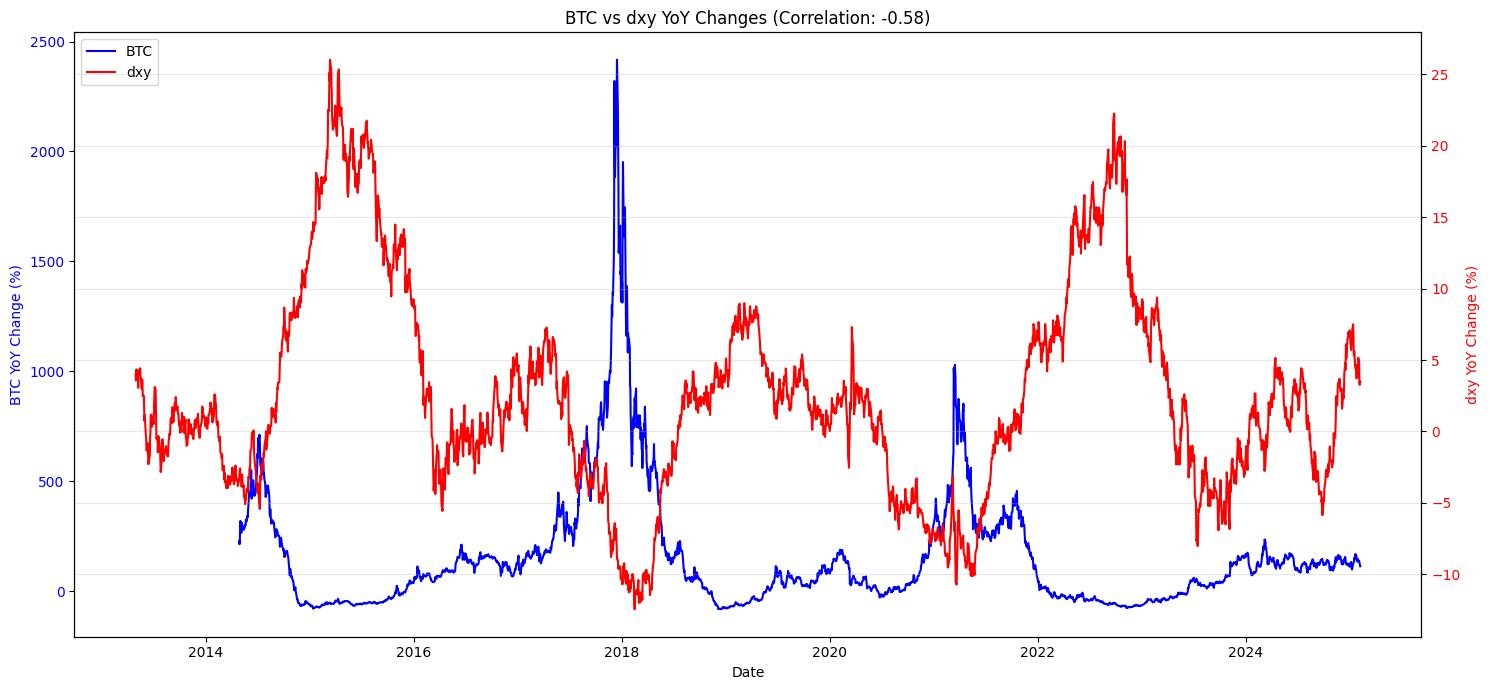


Analyzing move...


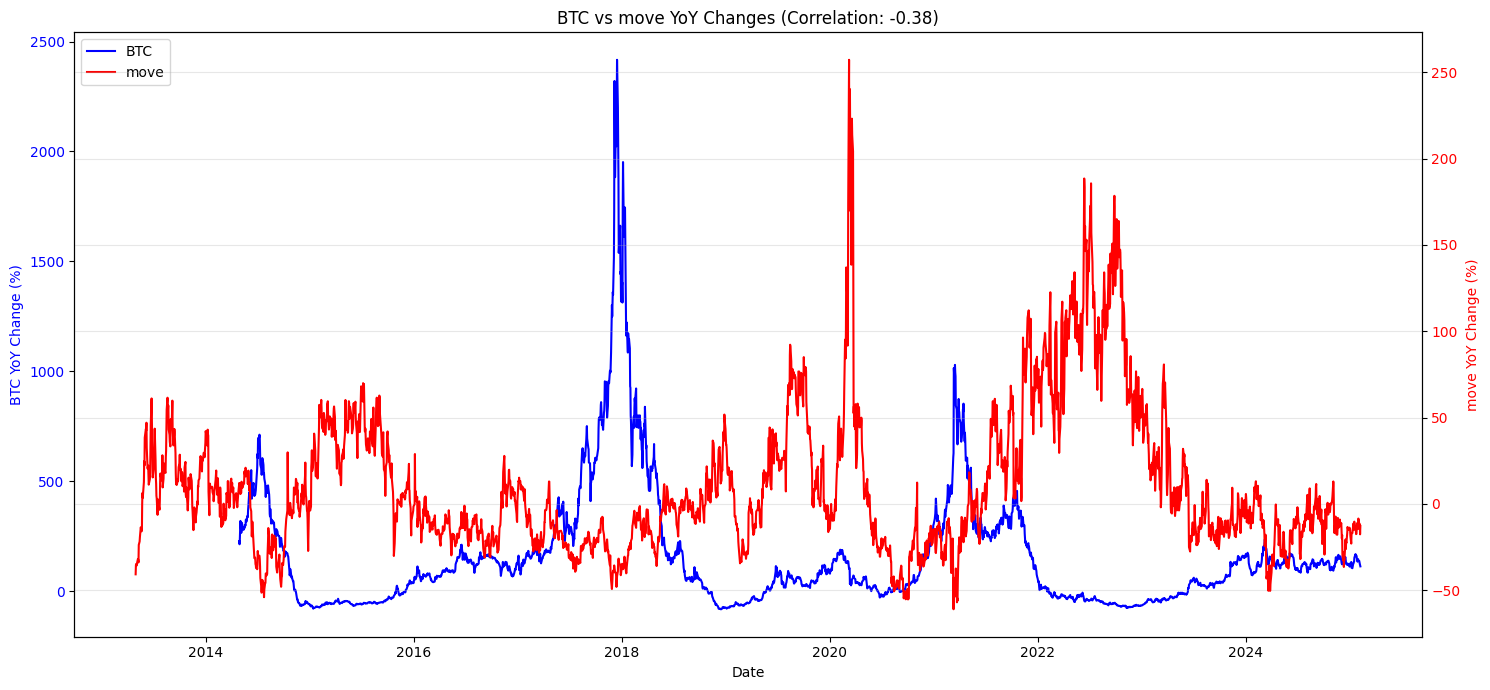


Analyzing treasury10Y2YSpread...


/Users/valter.rebelo/MissionControl/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:127: RuntimeWarning:

invalid value encountered in reduce



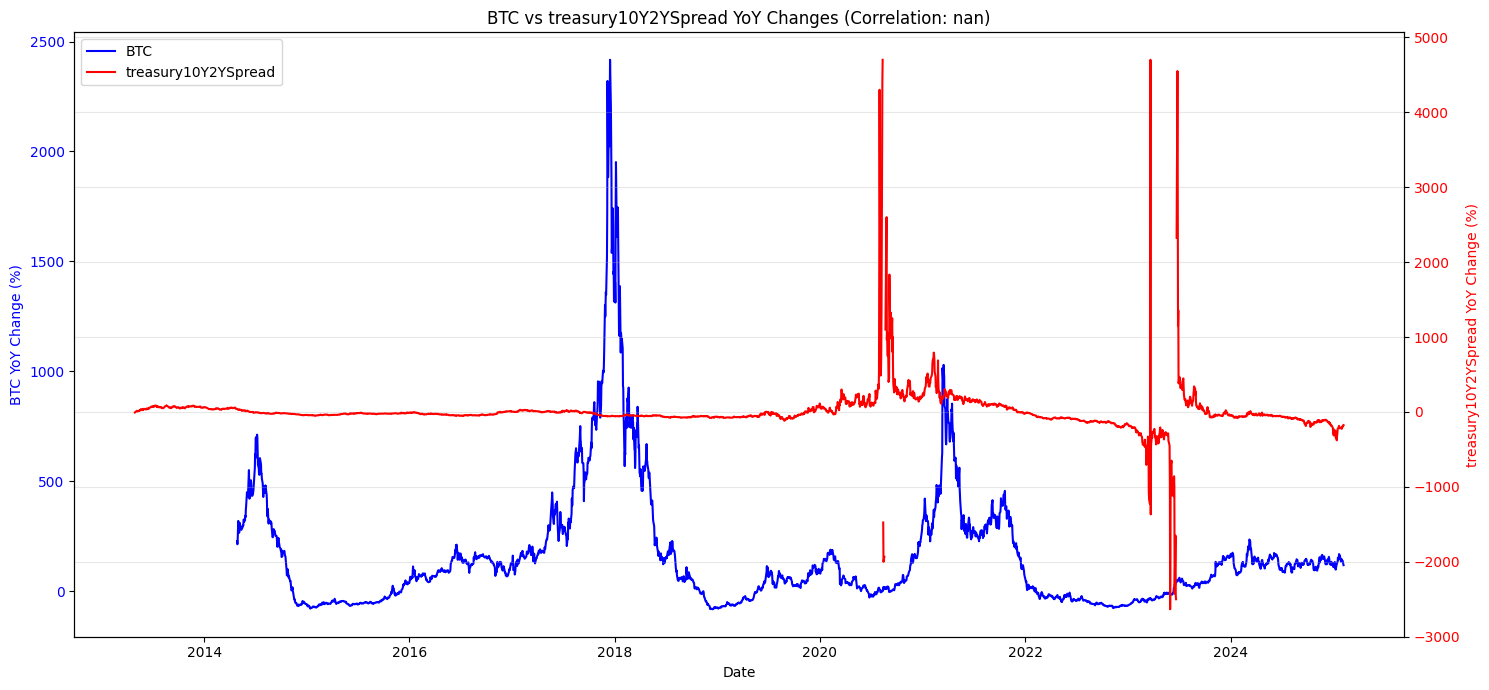


Analyzing credit spreads...


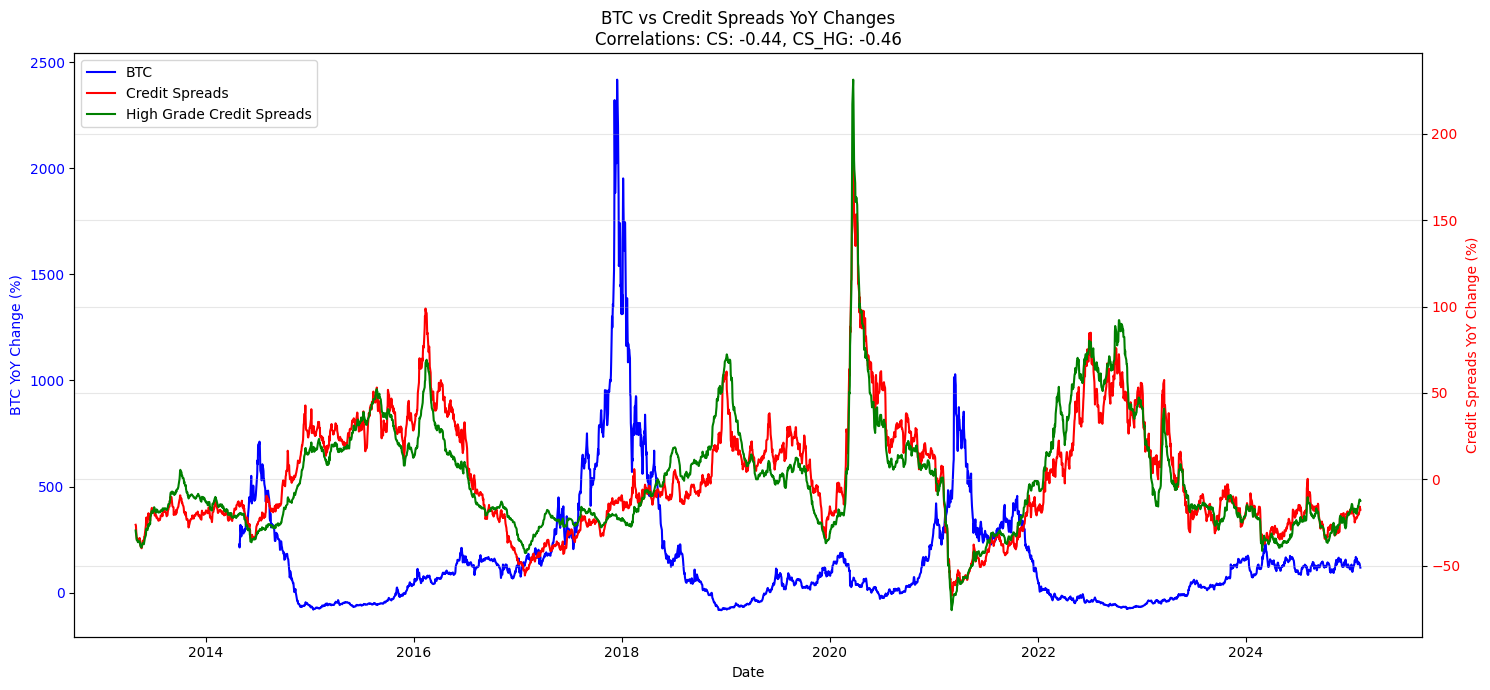


Correlation Summary:
              Variable  Correlation
4                  dxy    -0.575048
0              realGDP     0.381498
5                 move    -0.377537
3    globalCbLiquidity     0.166745
1    pceTrimmedMean12M    -0.166656
2                   m2     0.125312
6  treasury10Y2YSpread          NaN


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def load_and_prepare_btc():
    """Load BTC data and calculate YoY returns"""
    df = pd.read_csv('micro/assetData/bitcoin.csv')
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    df['BTC_YoY'] = df.iloc[:, 0].pct_change(365) * 100
    return df['BTC_YoY']

def load_macro_var(var_name):
    """Load macro variable data"""
    try:
        file_path = next(Path('macro/fredChanges').glob(f'{var_name}_changes_*.csv'))
        df = pd.read_csv(file_path)
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        return df['YoY']
    except Exception as e:
        print(f"Error loading {var_name}: {e}")
        return None

def plot_dual_axis(btc_data, macro_data, macro_name):
    """Create dual-axis time series plot"""
    # Merge the data
    merged = pd.merge(btc_data, macro_data, 
                     left_index=True, right_index=True,
                     how='inner')
    merged.columns = ['BTC_YoY', f'{macro_name}_YoY']
    
    # Calculate correlation
    corr = merged['BTC_YoY'].corr(merged[f'{macro_name}_YoY'])
    
    # Create the plot
    fig, ax1 = plt.subplots(figsize=(15, 7))
    
    # Plot BTC on primary axis
    color1 = 'blue'
    ax1.plot(merged.index, merged['BTC_YoY'], color=color1, label='BTC')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('BTC YoY Change (%)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create secondary axis
    ax2 = ax1.twinx()
    color2 = 'red'
    ax2.plot(merged.index, merged[f'{macro_name}_YoY'], color=color2, label=macro_name)
    ax2.set_ylabel(f'{macro_name} YoY Change (%)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Add title with correlation
    plt.title(f'BTC vs {macro_name} YoY Changes (Correlation: {corr:.2f})')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return corr

# Load BTC data
btc_data = load_and_prepare_btc()

# Variables to analyze
MACRO_VARS = [
    'realGDP',
    'creditSpreads',
    'creditSpreadsHighGrade',
    'pceTrimmedMean12M',
    'm2',
    'globalCbLiquidity',
    'dxy',
    'move',
    'treasury10Y2YSpread'
]

# Special case: plot credit spreads together
def plot_credit_spreads(btc_data):
    cs = load_macro_var('creditSpreads')
    cs_hg = load_macro_var('creditSpreadsHighGrade')
    
    if cs is not None and cs_hg is not None:
        merged = pd.merge(btc_data, cs, left_index=True, right_index=True, how='inner')
        merged = pd.merge(merged, cs_hg, left_index=True, right_index=True, how='inner')
        merged.columns = ['BTC_YoY', 'CS_YoY', 'CS_HG_YoY']
        
        fig, ax1 = plt.subplots(figsize=(15, 7))
        
        # Plot BTC
        color1 = 'blue'
        ax1.plot(merged.index, merged['BTC_YoY'], color=color1, label='BTC')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('BTC YoY Change (%)', color=color1)
        ax1.tick_params(axis='y', labelcolor=color1)
        
        # Plot credit spreads on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(merged.index, merged['CS_YoY'], color='red', label='Credit Spreads')
        ax2.plot(merged.index, merged['CS_HG_YoY'], color='green', label='High Grade Credit Spreads')
        ax2.set_ylabel('Credit Spreads YoY Change (%)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        
        # Add correlations to title
        corr1 = merged['BTC_YoY'].corr(merged['CS_YoY'])
        corr2 = merged['BTC_YoY'].corr(merged['CS_HG_YoY'])
        plt.title(f'BTC vs Credit Spreads YoY Changes\nCorrelations: CS: {corr1:.2f}, CS_HG: {corr2:.2f}')
        
        # Add legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Plot individual comparisons
results = []
for var_name in MACRO_VARS:
    if var_name not in ['creditSpreads', 'creditSpreadsHighGrade']:
        print(f"\nAnalyzing {var_name}...")
        macro_data = load_macro_var(var_name)
        if macro_data is not None:
            corr = plot_dual_axis(btc_data, macro_data, var_name)
            results.append({'Variable': var_name, 'Correlation': corr})

# Plot credit spreads together
print("\nAnalyzing credit spreads...")
plot_credit_spreads(btc_data)

# Display correlation summary
summary = pd.DataFrame(results)
summary = summary.sort_values('Correlation', key=abs, ascending=False)
print("\nCorrelation Summary:")
print(summary)


Analyzing realGDP...


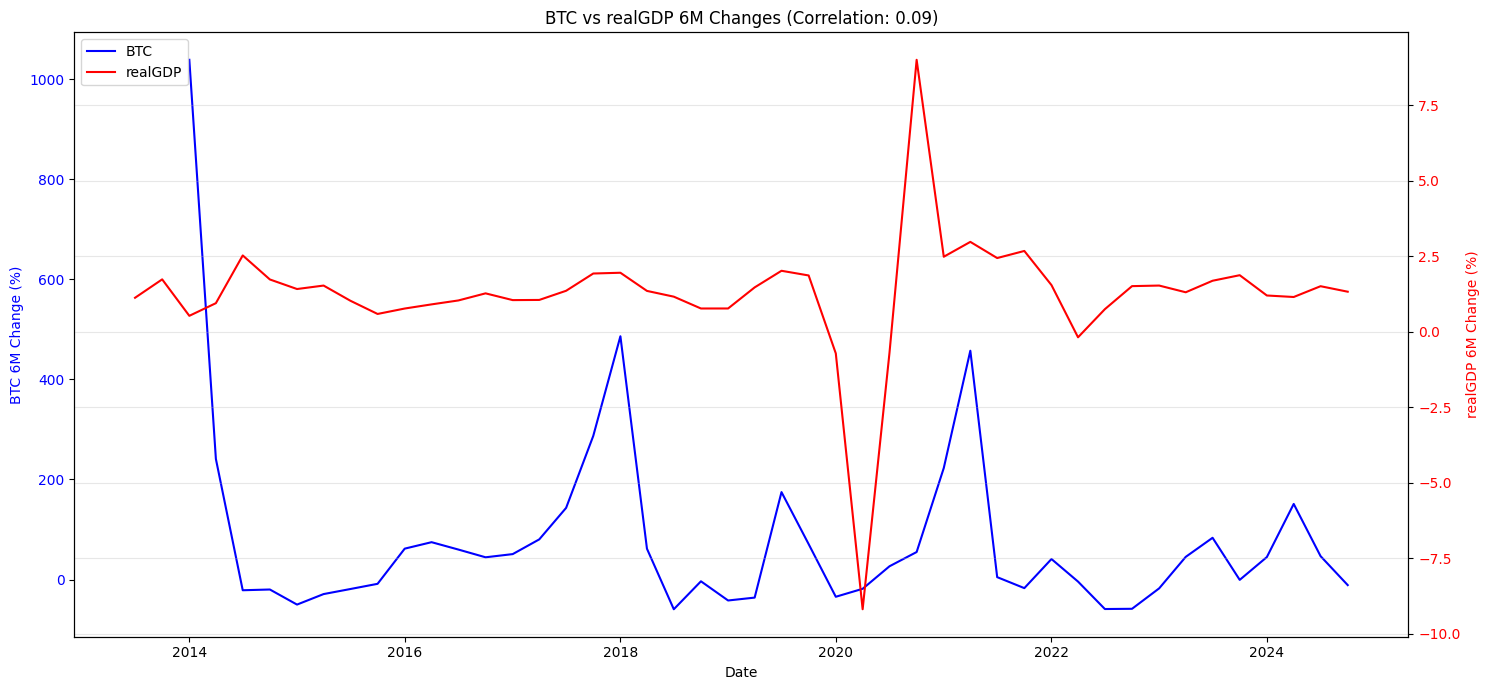


Analyzing pceTrimmedMean12M...


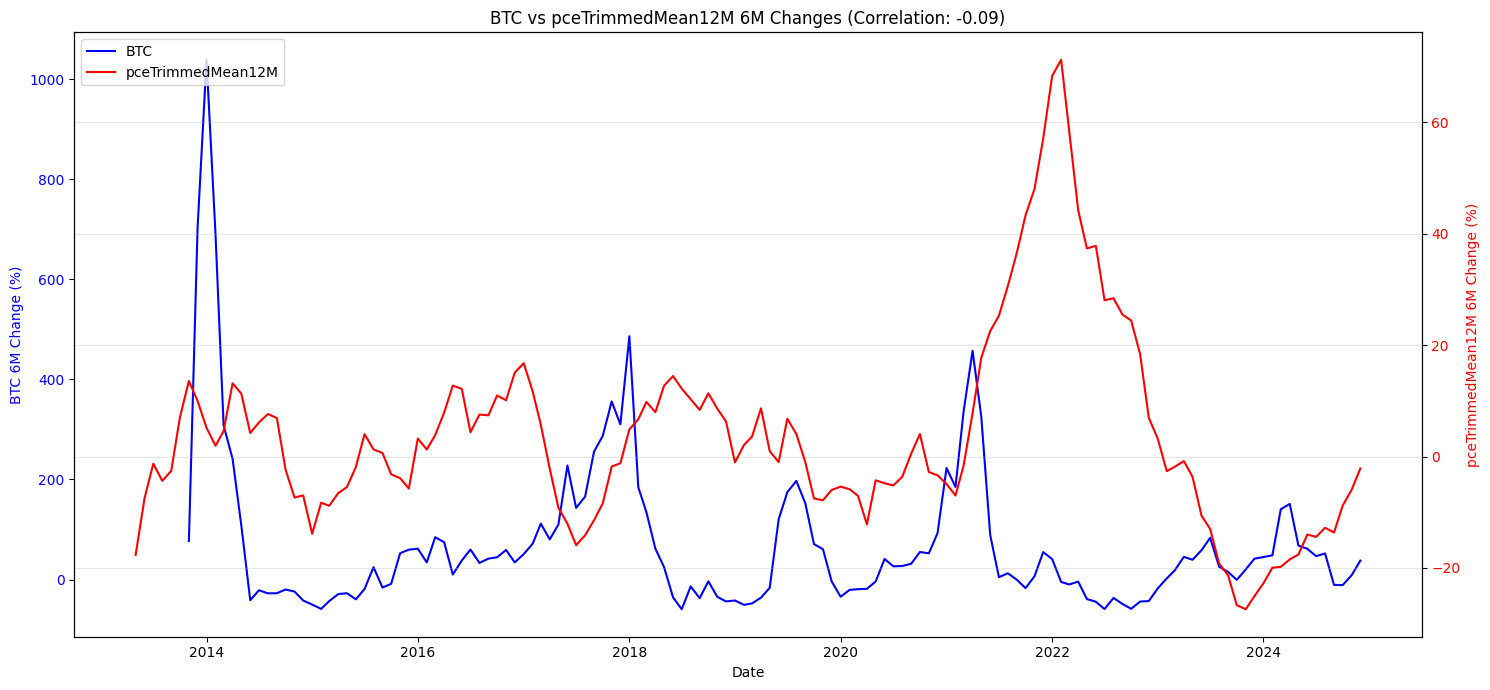


Analyzing m2...


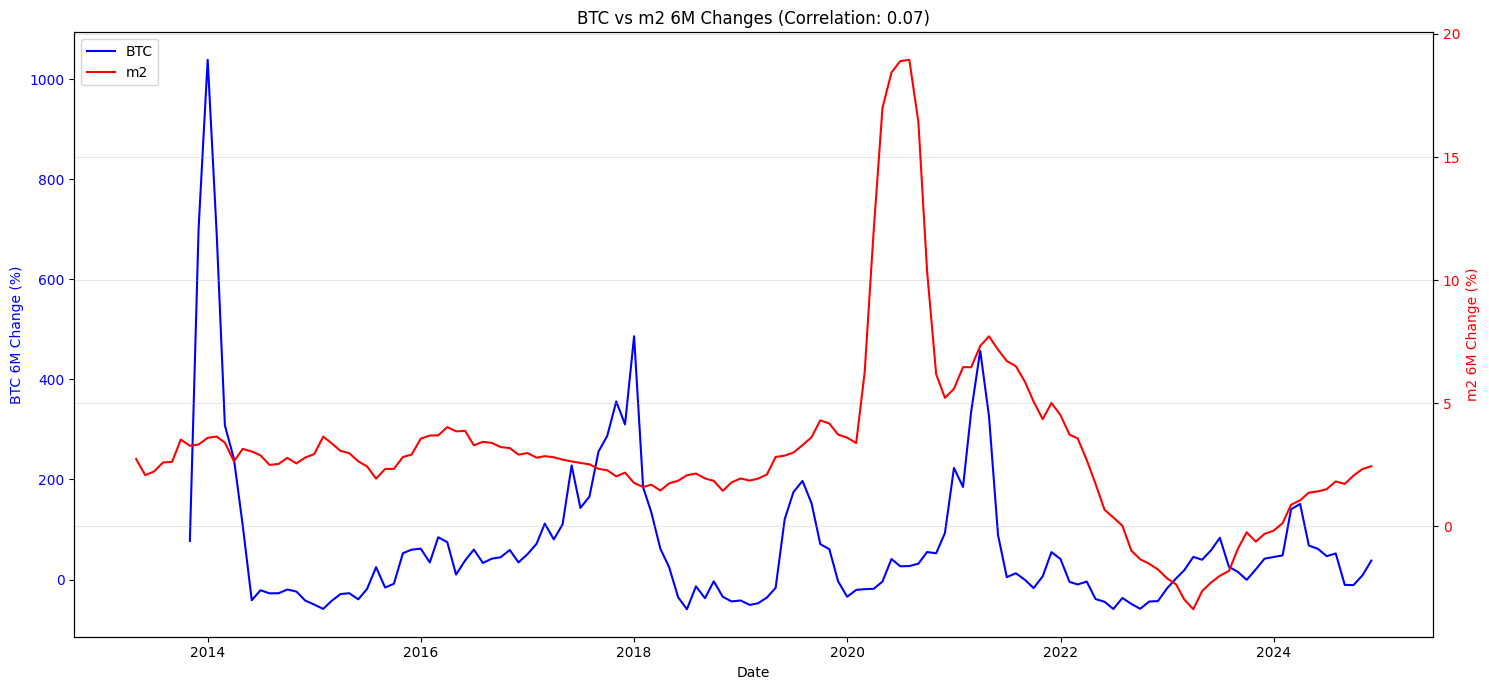


Analyzing globalCbLiquidity...


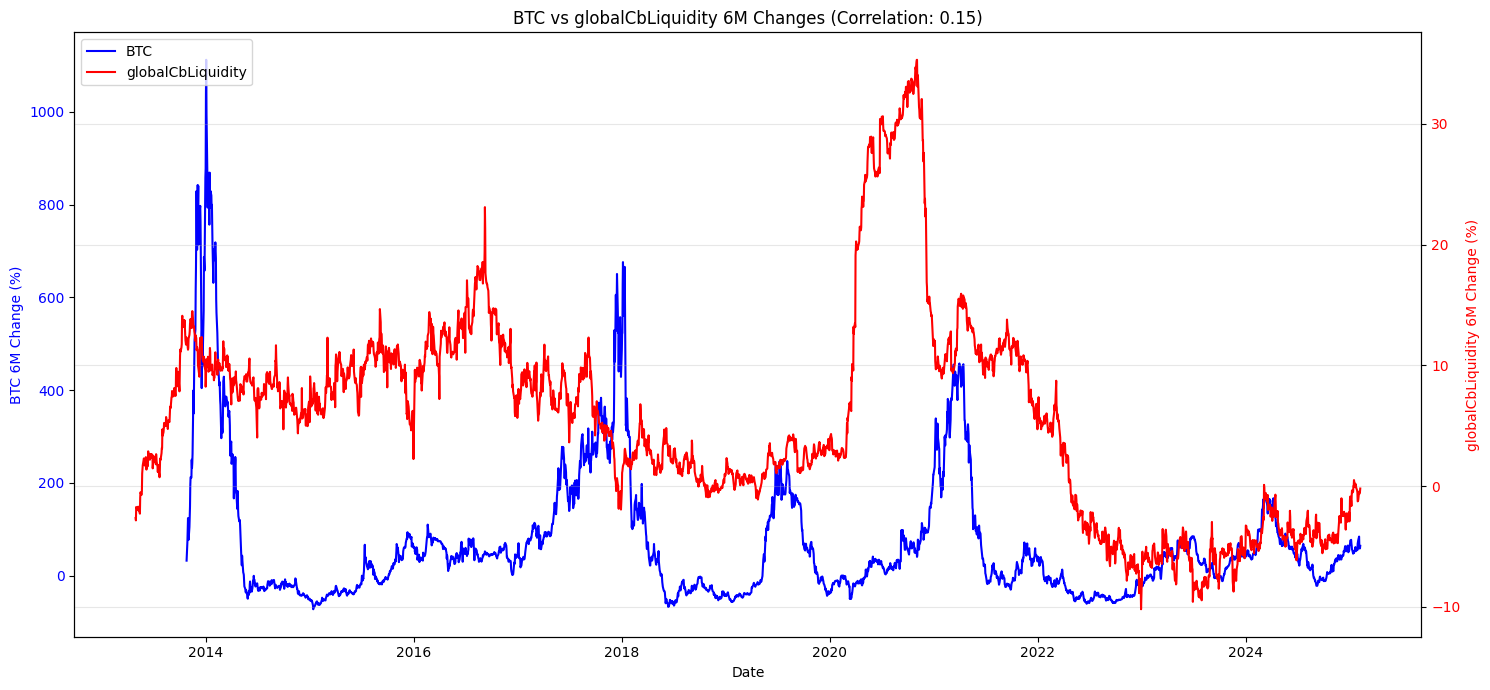


Analyzing dxy...


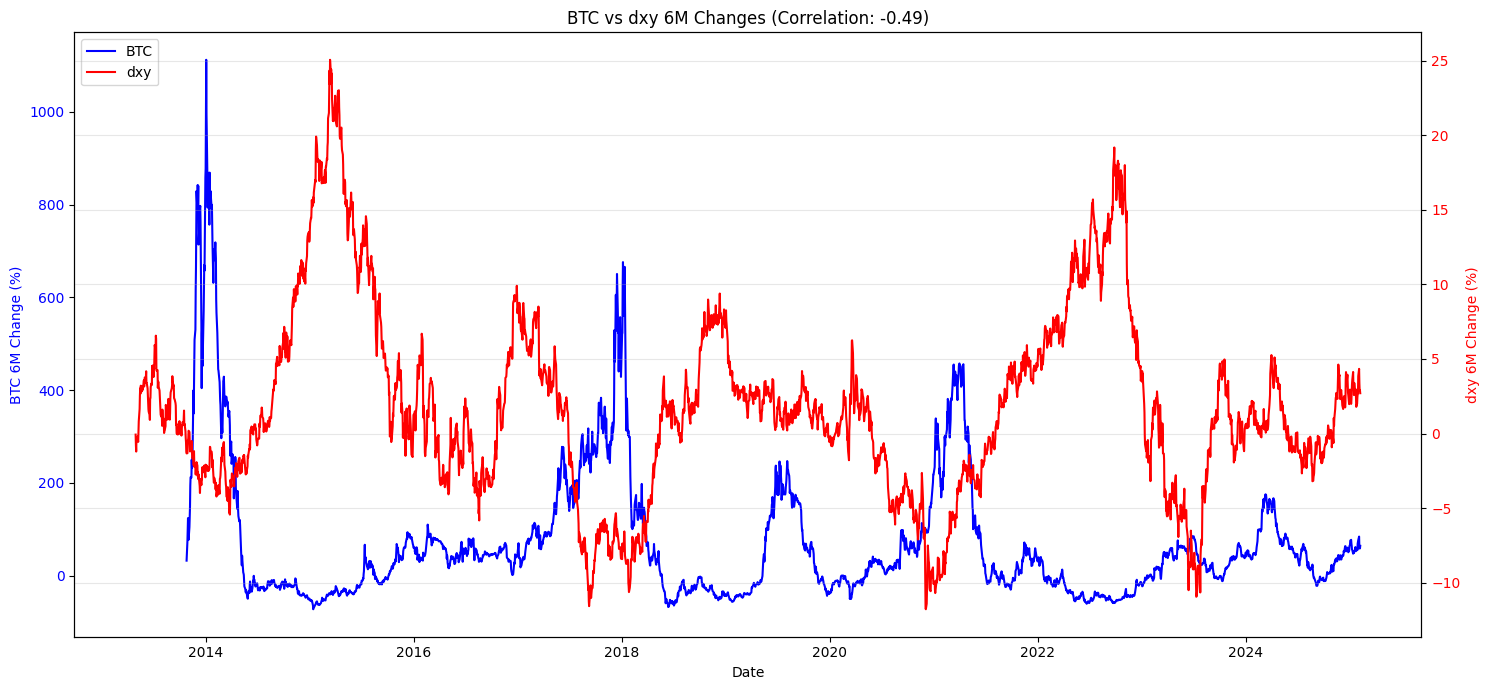


Analyzing move...


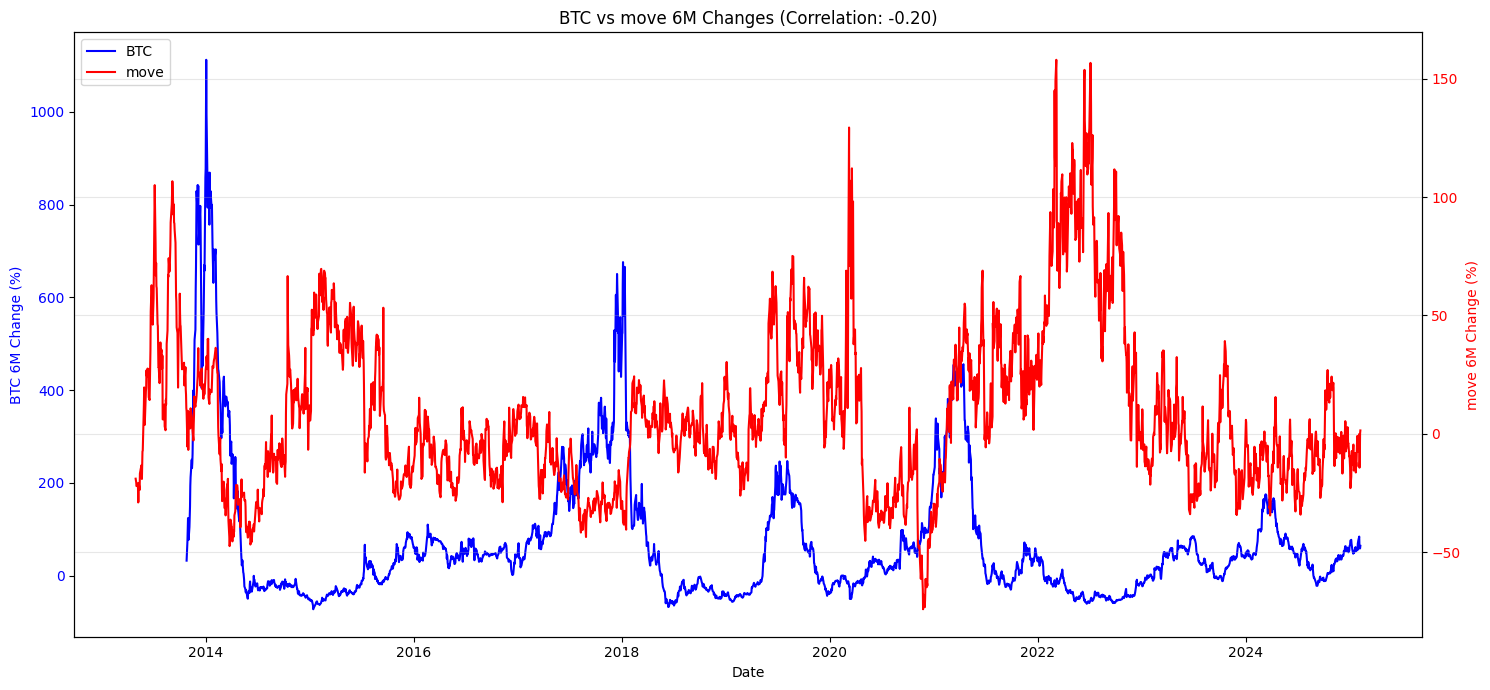


Analyzing coreStickiness...


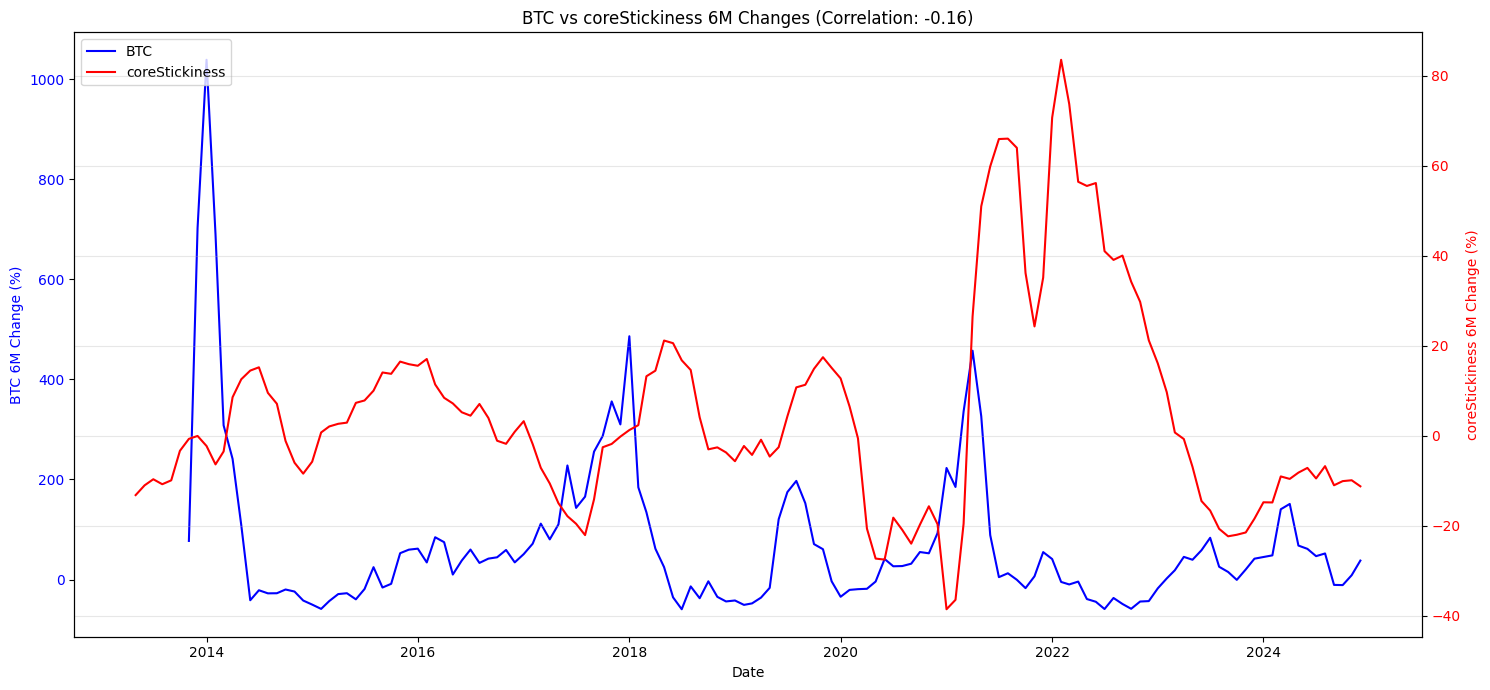


Analyzing credit spreads...


/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_73160/384891990.py:27: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_73160/384891990.py:27: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



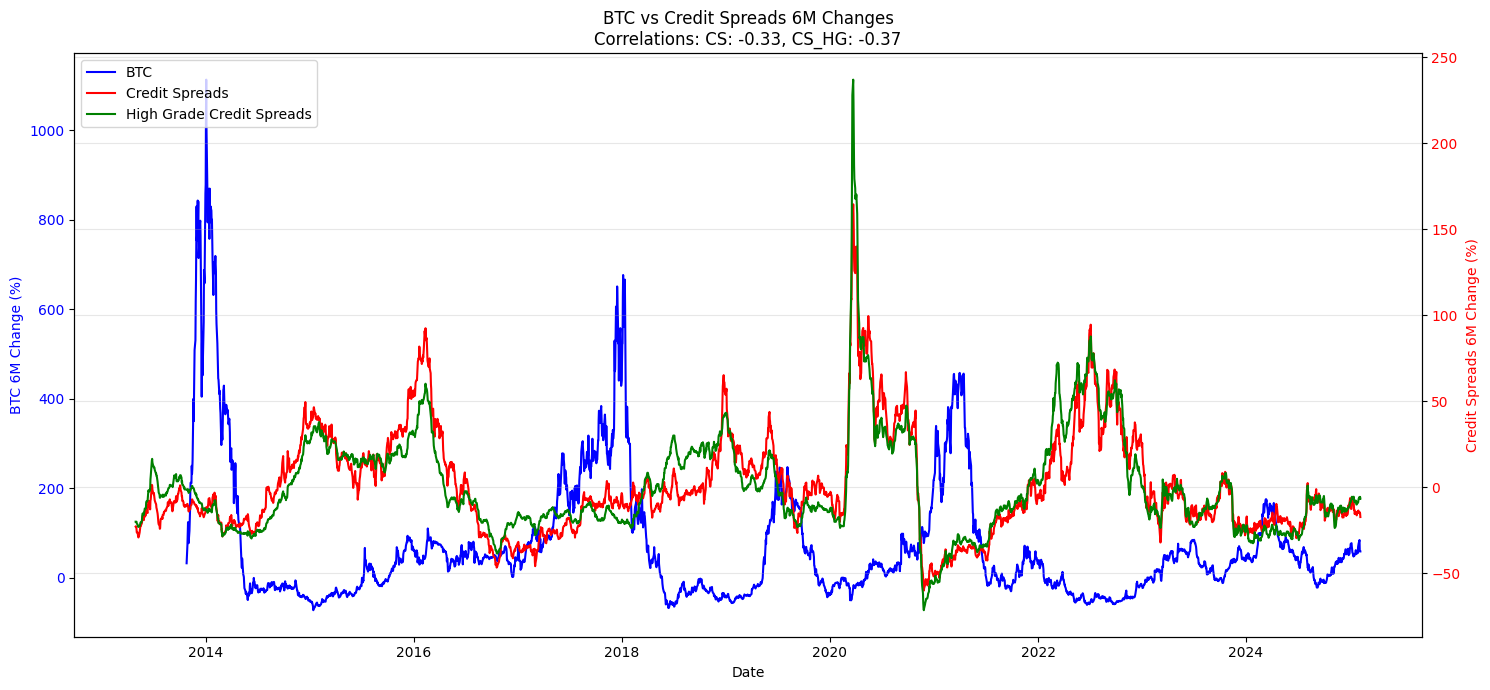


Correlation Summary:
            Variable  Correlation
4                dxy    -0.489599
5               move    -0.200113
6     coreStickiness    -0.164470
3  globalCbLiquidity     0.153602
1  pceTrimmedMean12M    -0.087815
0            realGDP     0.086978
2                 m2     0.073883


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def load_and_prepare_btc():
    """Load BTC data and calculate 6M returns"""
    df = pd.read_csv('micro/assetData/bitcoin.csv')
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    df['BTC_6M'] = df.iloc[:, 0].pct_change(180) * 100  # 180-day change
    return df['BTC_6M']

def load_macro_var(var_name):
    """Load macro variable data and calculate 6M change if needed"""
    try:
        file_path = next(Path('macro/fredChanges').glob(f'{var_name}_changes_*.csv'))
        df = pd.read_csv(file_path)
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        
        # If the data is daily, calculate 6M change
        # If it's monthly, use 6-period change
        # If it's quarterly, use 2-period change
        freq = detect_frequency(df.index)
        if freq == 'daily':
            df['6M'] = df.iloc[:, 0].pct_change(180) * 100
        elif freq == 'monthly':
            df['6M'] = df.iloc[:, 0].pct_change(6) * 100
        elif freq == 'quarterly':
            df['6M'] = df.iloc[:, 0].pct_change(2) * 100
        
        return df['6M']
    except Exception as e:
        print(f"Error loading {var_name}: {e}")
        return None

def detect_frequency(dates):
    """Detect the frequency of the data"""
    if len(dates) < 2:
        return None
    
    # Calculate average days between dates
    avg_days = (dates[-1] - dates[0]).days / (len(dates) - 1)
    
    if avg_days <= 3:  # Allow for some gaps
        return 'daily'
    elif avg_days <= 40:  # Roughly monthly
        return 'monthly'
    else:
        return 'quarterly'

def plot_dual_axis(btc_data, macro_data, macro_name):
    """Create dual-axis time series plot"""
    # Merge the data
    merged = pd.merge(btc_data, macro_data, 
                     left_index=True, right_index=True,
                     how='inner')
    merged.columns = ['BTC_6M', f'{macro_name}_6M']
    
    # Calculate correlation
    corr = merged['BTC_6M'].corr(merged[f'{macro_name}_6M'])
    
    # Create the plot
    fig, ax1 = plt.subplots(figsize=(15, 7))
    
    # Plot BTC on primary axis
    color1 = 'blue'
    ax1.plot(merged.index, merged['BTC_6M'], color=color1, label='BTC')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('BTC 6M Change (%)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create secondary axis
    ax2 = ax1.twinx()
    color2 = 'red'
    ax2.plot(merged.index, merged[f'{macro_name}_6M'], color=color2, label=macro_name)
    ax2.set_ylabel(f'{macro_name} 6M Change (%)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Add title with correlation
    plt.title(f'BTC vs {macro_name} 6M Changes (Correlation: {corr:.2f})')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return corr

def plot_credit_spreads(btc_data):
    """Special plot for both credit spread measures"""
    cs = load_macro_var('creditSpreads')
    cs_hg = load_macro_var('creditSpreadsHighGrade')
    
    if cs is not None and cs_hg is not None:
        merged = pd.merge(btc_data, cs, left_index=True, right_index=True, how='inner')
        merged = pd.merge(merged, cs_hg, left_index=True, right_index=True, how='inner')
        merged.columns = ['BTC_6M', 'CS_6M', 'CS_HG_6M']
        
        fig, ax1 = plt.subplots(figsize=(15, 7))
        
        # Plot BTC
        color1 = 'blue'
        ax1.plot(merged.index, merged['BTC_6M'], color=color1, label='BTC')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('BTC 6M Change (%)', color=color1)
        ax1.tick_params(axis='y', labelcolor=color1)
        
        # Plot credit spreads on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(merged.index, merged['CS_6M'], color='red', label='Credit Spreads')
        ax2.plot(merged.index, merged['CS_HG_6M'], color='green', label='High Grade Credit Spreads')
        ax2.set_ylabel('Credit Spreads 6M Change (%)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        
        # Add correlations to title
        corr1 = merged['BTC_6M'].corr(merged['CS_6M'])
        corr2 = merged['BTC_6M'].corr(merged['CS_HG_6M'])
        plt.title(f'BTC vs Credit Spreads 6M Changes\nCorrelations: CS: {corr1:.2f}, CS_HG: {corr2:.2f}')
        
        # Add legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Load BTC data
btc_data = load_and_prepare_btc()

# Variables to analyze
MACRO_VARS = [
    'realGDP',
    'creditSpreads',
    'creditSpreadsHighGrade',
    'pceTrimmedMean12M',
    'm2',
    'globalCbLiquidity',
    'dxy',
    'move',
    'coreStickiness'
]

# Plot individual comparisons
results = []
for var_name in MACRO_VARS:
    if var_name not in ['creditSpreads', 'creditSpreadsHighGrade']:
        print(f"\nAnalyzing {var_name}...")
        macro_data = load_macro_var(var_name)
        if macro_data is not None:
            corr = plot_dual_axis(btc_data, macro_data, var_name)
            results.append({'Variable': var_name, 'Correlation': corr})

# Plot credit spreads together
print("\nAnalyzing credit spreads...")
plot_credit_spreads(btc_data)

# Display correlation summary
summary = pd.DataFrame(results)
summary = summary.sort_values('Correlation', key=abs, ascending=False)
print("\nCorrelation Summary:")
print(summary)

In [30]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

# Load BTC data and calculate weekly returns
btc = pd.read_csv('micro/assetData/bitcoin.csv')
btc['date'] = pd.to_datetime(btc['date'])
btc.set_index('date', inplace=True)
btc['BTC_Weekly'] = btc.iloc[:, 0].pct_change(7) * 100  # 7-day change

# Load yield curve regime data
yc = pd.read_csv('macro/fredChanges/yieldCurveRegime_changes_daily.csv')
yc['date'] = pd.to_datetime(yc['date'])
yc.set_index('date', inplace=True)

# Merge data
merged = pd.merge(btc['BTC_Weekly'], yc[['regime', 'color']], 
                 left_index=True, right_index=True, 
                 how='left')

# Remove NaN values
merged = merged.dropna()

# Calculate statistics for each regime
regime_stats = {}
for regime in merged['regime'].unique():
    regime_data = merged[merged['regime'] == regime]['BTC_Weekly']
    regime_stats[regime] = {
        'mean': regime_data.mean(),
        'median': regime_data.median(),
        'std': regime_data.std(),
        'count': len(regime_data),
        'min': regime_data.min(),
        'max': regime_data.max()
    }

# Convert to DataFrame for easy display
stats_df = pd.DataFrame(regime_stats).round(2)
print("\nBTC Weekly Returns Statistics by Regime:")
print(stats_df)

# Perform one-way ANOVA to test if returns are significantly different across regimes
regimes = merged['regime'].unique()
regime_groups = [merged[merged['regime'] == regime]['BTC_Weekly'].dropna() for regime in regimes]
f_stat, p_value = stats.f_oneway(*regime_groups)

print(f"\nOne-way ANOVA test:")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.4f}")

# Calculate mean returns for each regime
mean_returns = merged.groupby('regime')['BTC_Weekly'].agg(['mean', 'count']).round(2)
print("\nMean Returns by Regime:")
print(mean_returns)

# Create box plot of returns by regime
fig = go.Figure()

for regime in merged['regime'].unique():
    regime_data = merged[merged['regime'] == regime]['BTC_Weekly']
    color = merged[merged['regime'] == regime]['color'].iloc[0]
    
    fig.add_trace(go.Box(
        y=regime_data,
        name=regime,
        marker_color=color,
        boxpoints='outliers'
    ))

fig.update_layout(
    title='Distribution of BTC Weekly Returns by Yield Curve Regime',
    yaxis_title='BTC Weekly Returns (%)',
    showlegend=True,
    height=600,
    width=1000,
    template='plotly_white'
)

fig.show()

# Additional analysis: Calculate probability of positive returns in each regime
prob_positive = merged.groupby('regime').apply(
    lambda x: (x['BTC_Weekly'] > 0).mean() * 100
).round(2)

print("\nProbability of Positive Weekly Returns by Regime (%):")
print(prob_positive)

# Calculate volatility (annualized) for each regime
annualized_vol = merged.groupby('regime')['BTC_Weekly'].std() * np.sqrt(52)

print("\nAnnualized Volatility by Regime (%):")
print(annualized_vol.round(2))


BTC Weekly Returns Statistics by Regime:
        flattener_twist  bull_flattener  bull_steepener  bear_steepener  \
mean               8.52            1.82            2.67            0.26   
median             4.62            1.55            1.38            0.16   
std               17.38           10.22           11.00            9.38   
count            180.00          634.00          270.00          679.00   
min              -27.98          -41.82          -43.10          -38.24   
max               87.31           61.76           45.00           39.06   

        neutral  bear_flattener  steepener_twist  
mean       1.13            1.14             0.75  
median     0.42           -0.01            -0.30  
std        8.85           11.13            10.15  
count    249.00          463.00           347.00  
min      -21.98          -32.20           -32.37  
max       36.26           77.69            41.69  

One-way ANOVA test:
F-statistic: 15.31
p-value: 0.0000

Mean Returns by Re


Probability of Positive Weekly Returns by Regime (%):
regime
bear_flattener     49.89
bear_steepener     51.55
bull_flattener     56.62
bull_steepener     59.63
flattener_twist    68.33
neutral            52.21
steepener_twist    48.13
dtype: float64

Annualized Volatility by Regime (%):
regime
bear_flattener      80.26
bear_steepener      67.61
bull_flattener      73.71
bull_steepener      79.30
flattener_twist    125.33
neutral             63.83
steepener_twist     73.21
Name: BTC_Weekly, dtype: float64


/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_73160/4164425156.py:84: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [32]:
import pandas as pd
import plotly.graph_objects as go

# Load yield curve regime data
yc = pd.read_csv('macro/fredData/yieldCurveRegime.csv')
yc['date'] = pd.to_datetime(yc['date'])
yc = yc[yc['date'] >= '2010-01-01']
yc['year'] = yc['date'].dt.year

# Get value counts by year and regime
yearly_counts = pd.crosstab(yc['year'], yc['regime'])

# Create stacked bar chart
fig = go.Figure()

# Define custom colors for each regime
colors = {
    'bull_steepener': '#03C04A',  # Green
    'bull_flattener': '#0492C2',  # Blue
    'bear_steepener': '#FF0000',  # Red
    'bear_flattener': '#9867C5',  # Purple
    'flattener_twist': '#FCE205',  # Yellow
    'steepener_twist': '#FFA500',  # Orange
    'neutral': '#FFFFFF'          # White
}

# Add traces for each regime
for regime in yearly_counts.columns:
    fig.add_trace(go.Bar(
        name=regime,
        x=yearly_counts.index,
        y=yearly_counts[regime],
        marker_color=colors[regime]
    ))

# Update layout
fig.update_layout(
    title='Distribution of Yield Curve Regimes by Year',
    xaxis_title='Year',
    yaxis_title='Number of Days',
    barmode='stack',
    showlegend=True,
    height=800,
    width=1200,
    template='plotly_white'
)

# Show plot
fig.show()

# Print summary statistics
print("\nTotal days in each regime:")
total_counts = yc['regime'].value_counts()
print(total_counts)

print("\nPercentage of time in each regime:")
percentage_counts = (yc['regime'].value_counts() / len(yc) * 100).round(2)
print(percentage_counts)


Total days in each regime:
regime
bull_flattener     941
bear_steepener     872
bear_flattener     497
steepener_twist    416
neutral            334
bull_steepener     305
flattener_twist    261
Name: count, dtype: int64

Percentage of time in each regime:
regime
bull_flattener     25.95
bear_steepener     24.05
bear_flattener     13.71
steepener_twist    11.47
neutral             9.21
bull_steepener      8.41
flattener_twist     7.20
Name: count, dtype: float64


In [33]:
import pandas as pd
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.graph_objects as go
from scipy import stats

# Load BTC data and calculate weekly returns
btc = pd.read_csv('micro/assetData/bitcoin.csv')
btc['date'] = pd.to_datetime(btc['date'])
btc.set_index('date', inplace=True)
btc['BTC_Weekly'] = btc.iloc[:, 0].pct_change(7) * 100

# Load yield curve regime data
yc = pd.read_csv('macro/fredChanges/yieldCurveRegime_changes_daily.csv')
yc['date'] = pd.to_datetime(yc['date'])
yc.set_index('date', inplace=True)

# Merge data
merged = pd.merge(btc['BTC_Weekly'], yc[['regime', 'color']], 
                 left_index=True, right_index=True, 
                 how='left')

# Remove NaN values
merged = merged.dropna()

# Prepare data for Tukey's test
returns = merged['BTC_Weekly']
groups = merged['regime']

# Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(returns, groups)

# Convert results to DataFrame for easier viewing
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

# Print Tukey's test results
print("\nTukey's HSD test results:")
print(tukey_df)

# Create a heatmap of p-values
unique_regimes = sorted(groups.unique())
n_regimes = len(unique_regimes)
p_values = np.zeros((n_regimes, n_regimes))

for i, regime1 in enumerate(unique_regimes):
    for j, regime2 in enumerate(unique_regimes):
        if i < j:  # Only need to fill upper triangle
            mask = (tukey_df['group1'] == regime1) & (tukey_df['group2'] == regime2)
            if mask.any():
                p_values[i, j] = float(tukey_df.loc[mask, 'p-adj'])
                p_values[j, i] = p_values[i, j]  # Mirror the p-values
        elif i == j:
            p_values[i, j] = 1.0  # Diagonal should be 1

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=p_values,
    x=unique_regimes,
    y=unique_regimes,
    colorscale='RdBu',
    zmin=0,
    zmax=1,
    text=np.round(p_values, 4),
    texttemplate='%{text}',
    textfont={"size": 10},
    hoverongaps=False
))

fig.update_layout(
    title='P-values from Tukey\'s HSD Test (Regime Comparisons)',
    width=1000,
    height=800
)

# Show the heatmap
fig.show()

# Calculate effect sizes (Cohen's d) for significant comparisons
print("\nEffect sizes (Cohen's d) for significant comparisons:")
for regime1 in unique_regimes:
    for regime2 in unique_regimes:
        if regime1 < regime2:  # Avoid duplicate comparisons
            group1_data = merged[merged['regime'] == regime1]['BTC_Weekly']
            group2_data = merged[merged['regime'] == regime2]['BTC_Weekly']
            
            # Calculate Cohen's d
            n1, n2 = len(group1_data), len(group2_data)
            var1, var2 = np.var(group1_data, ddof=1), np.var(group2_data, ddof=1)
            
            # Pooled standard deviation
            pooled_se = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
            
            if pooled_se != 0:  # Avoid division by zero
                cohens_d = (np.mean(group1_data) - np.mean(group2_data)) / pooled_se
                
                # Get p-value from Tukey results
                mask = (tukey_df['group1'] == regime1) & (tukey_df['group2'] == regime2)
                if mask.any():
                    p_value = float(tukey_df.loc[mask, 'p-adj'])
                    
                    if p_value < 0.05:  # Only print significant differences
                        print(f"{regime1} vs {regime2}:")
                        print(f"  Cohen's d: {cohens_d:.3f}")
                        print(f"  p-value: {p_value:.4f}")


Tukey's HSD test results:
             group1           group2  meandiff   p-adj    lower    upper  \
0    bear_flattener   bear_steepener   -0.8809  0.8225  -2.7907   1.0288   
1    bear_flattener   bull_flattener    0.6817  0.9451  -1.2552   2.6187   
2    bear_flattener   bull_steepener    1.5305  0.5065  -0.8957   3.9568   
3    bear_flattener  flattener_twist    7.3865  0.0000   4.6033  10.1697   
4    bear_flattener          neutral   -0.0084  1.0000  -2.4984   2.4817   
5    bear_flattener  steepener_twist   -0.3915  0.9987  -2.6413   1.8583   
6    bear_steepener   bull_flattener    1.5627  0.1160  -0.1872   3.3126   
7    bear_steepener   bull_steepener    2.4115  0.0301   0.1318   4.6912   
8    bear_steepener  flattener_twist    8.2674  0.0000   5.6111  10.9238   
9    bear_steepener          neutral    0.8726  0.9292  -1.4749   3.2201   
10   bear_steepener  steepener_twist    0.4894  0.9931  -1.6015   2.5803   
11   bull_flattener   bull_steepener    0.8488  0.9319  -1.45

/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_73160/654987410.py:53: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead




Effect sizes (Cohen's d) for significant comparisons:
bear_flattener vs flattener_twist:
  Cohen's d: -0.561
  p-value: 0.0000
bear_steepener vs bull_steepener:
  Cohen's d: -0.244
  p-value: 0.0301
bear_steepener vs flattener_twist:
  Cohen's d: -0.718
  p-value: 0.0000
bull_flattener vs flattener_twist:
  Cohen's d: -0.551
  p-value: 0.0000
bull_steepener vs flattener_twist:
  Cohen's d: -0.421
  p-value: 0.0000
flattener_twist vs neutral:
  Cohen's d: 0.564
  p-value: 0.0000
flattener_twist vs steepener_twist:
  Cohen's d: 0.595
  p-value: 0.0000


/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_73160/654987410.py:102: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

